In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [69]:
#for exploring dataframe
import numpy as np
import pandas as pd

#for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#for interactivity
from ipywidgets import interact

#for animated graphs
import plotly.express as px
import plotly.graph_objects as go

#to ignore warnings
import warnings
warnings.filterwarnings('ignore')

#importing libraries for machine learning
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn import metrics

In [6]:
df = pd.read_csv('dataset.csv')

In [7]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42.0,43.0,20.879744,82.002744,6.502985,203.983200,100.0
1,85,58.0,41.0,22.000940,80.319644,7.038096,226.655537,100.0
2,60,55.0,44.0,23.004459,82.320763,7.840207,263.964248,100.0
3,74,35.0,40.0,26.491096,80.158363,6.980401,242.864034,100.0
4,78,42.0,42.0,20.130175,81.604873,7.628473,262.717340,100.0
...,...,...,...,...,...,...,...,...
1595,40,120.0,197.0,23.805938,92.488795,5.889481,119.633555,3.0
1596,25,132.0,198.0,22.319441,90.851744,5.732758,100.117344,3.0
1597,31,137.0,196.0,22.144641,93.825674,6.400321,120.631078,3.0
1598,36,144.0,196.0,23.651676,94.505288,6.496934,115.361127,3.0


In [8]:
df.shape

(1600, 8)

In [9]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42.0,43.0,20.879744,82.002744,6.502985,203.983200,100.0
1,85,58.0,41.0,22.000940,80.319644,7.038096,226.655537,100.0
2,60,55.0,44.0,23.004459,82.320763,7.840207,263.964248,100.0
3,74,35.0,40.0,26.491096,80.158363,6.980401,242.864034,100.0
4,78,42.0,42.0,20.130175,81.604873,7.628473,262.717340,100.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            1600 non-null   int64  
 1   P            1599 non-null   float64
 2   K            1599 non-null   float64
 3   temperature  1598 non-null   float64
 4   humidity     1597 non-null   float64
 5   ph           1598 non-null   float64
 6   rainfall     1598 non-null   float64
 7   label        1599 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 100.1 KB


In [11]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall,label
count,1600.000000,1599.000000,1599.000000,1598.000000,1597.000000,1598.000000,1598.000000,1599.000000
mean,45.216875,59.940588,54.949969,25.354778,67.182337,6.388412,89.679984,49.563477
std,34.513593,34.888535,57.389748,4.890815,23.487416,0.827376,51.242819,31.099897
min,0.000000,5.000000,15.000000,8.825675,14.258040,3.504752,19.644500,3.000000
25%,19.000000,36.000000,21.000000,21.910786,53.505676,5.858917,54.944836,20.000000
50%,33.000000,58.000000,35.000000,25.564526,75.264298,6.322607,78.210586,58.000000
75%,78.000000,74.000000,52.000000,28.694666,85.499382,6.834696,107.833854,75.500000
max,120.000000,145.000000,205.000000,41.948657,94.998975,9.935091,298.560117,100.000000


<Axes: >

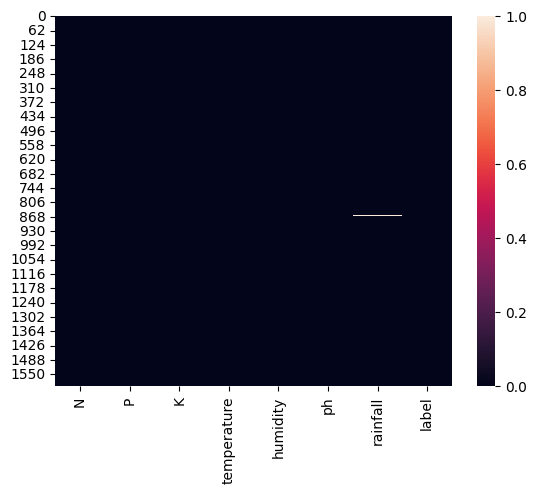

In [12]:
sns.heatmap(df.isnull())

In [13]:
df.isna().sum()

N              0
P              1
K              1
temperature    2
humidity       3
ph             2
rainfall       2
label          1
dtype: int64

## Data Cleaning

In [14]:
df.P = df.P.fillna(value = 0)
df.K = df.K.fillna(value = 0)

In [15]:
df.temperature = df.temperature.fillna(value = df.temperature.mean())
df.humidity = df.humidity.fillna(value = df.humidity.mean())
df.ph = df.ph.fillna(value = df.ph.mean())
df.rainfall = df.rainfall.fillna(value = df.rainfall.mean())

In [16]:
df.label = df.label.fillna(value = df.label.mode()[0])

In [17]:
df.isna().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [18]:
df['label'].value_counts()

3.0      101
100.0    100
72.0     100
86.0     100
65.0     100
79.0     100
58.0     100
92.0     100
67.0     100
36.0     100
28.0     100
23.0     100
17.0     100
11.0     100
8.0      100
48.0      99
Name: label, dtype: int64

## Exploratory Data Analysis

### Statistical Study

In [19]:
@interact
def summary(Percentage= list(df['label'].value_counts().index)):
    x = df[df['label']==Percentage]
    print("____________________________________________________")
    print("Statistics for Nitrogen")
    print('Minimum Nitrogen Required: ',x['N'].min())
    print('Average Nitrogen Required: ',x['N'].mean())
    print('Maximum Nitrogen Required: ',x['N'].max())


    print("____________________________________________________")
    print("Statistics for Phosphrus")
    print('Minimum Phosphorus Required: ',x['P'].min())
    print('Average Phosphorus Required: ',x['P'].mean())
    print('Maximum Phosphorus Required: ',x['P'].max())

    print("____________________________________________________")
    print("Statistics for Pottasium")
    print('Minimum Pottasium Required: ',x['K'].min())
    print('Average Pottasium Required: ',x['K'].mean())
    print('Maximum Pottaisum Required: ',x['K'].max())

    print("____________________________________________________")
    print("Statistics for Temperature")
    print('Minimum Temperature Required: {:.2f}'.format(x['temperature'].min()))
    print('Average Temperature Required: {:.2f}'.format(x['temperature'].mean()))
    print('Maximum Temperature Required: {:.2f}'.format(x['temperature'].max()))


    print("____________________________________________________")
    print("Statistics for Humidity")
    print('Minimum Humidity Required: {:.2f}'.format(x['humidity'].min()))
    print('Average Humidity Required: {:.2f}'.format(x['humidity'].mean()))
    print('Maximum Humidity Required: {:.2f}'.format(x['humidity'].max()))

    print("____________________________________________________")
    print("Statistics for ph")
    print('Minimum ph Required: {:.2f}'.format(x['ph'].min()))
    print('Average ph Required: {:.2f}'.format(x['ph'].mean()))
    print('Maximum ph Required: {:.2f}'.format(x['ph'].max()))


    print("____________________________________________________")
    print("Statistics for Rainfall")
    print('Minimum Rainfall Required: {:.2f} '.format(x['rainfall'].min()))
    print('Average Rainfall Required: {:.2f}'.format(x['rainfall'].mean()))
    print('Maximum Rainfall Required: {:.2f}'.format(x['rainfall'].max()))

interactive(children=(Dropdown(description='Percentage', options=(3.0, 100.0, 72.0, 86.0, 65.0, 79.0, 58.0, 92…

In [20]:
@interact
def compare(condition=['N','P','K','temperature','ph','humidity','rainfall']):
    print("Average value for: {:.2f}".format(df[condition].mean()))
    print("-----------------------------------------------------")
    print("48: {0:.2f}".format(df[(df['label']=='48')][condition].mean()))
    print("67: {0:.2f}".format(df[(df['label']=='67')][condition].mean()))
    print("92: {0:.2f}".format(df[(df['label']=='92')][condition].mean()))
    print("36: {0:.2f}".format(df[(df['label']=='36')][condition].mean()))

interactive(children=(Dropdown(description='condition', options=('N', 'P', 'K', 'temperature', 'ph', 'humidity…

In [21]:
@interact
def compare(condition=['N','P','K','temperature','ph','humidity','rainfall']):
    print(f"Crops which require greater {condition} than than average",'\n')
    print(df[df[condition] > df[condition].mean()]['label'].unique())
    print("------------------------------------------------")
    print(f"Crops which require lesser {condition} than than average",'\n')
    print(df[df[condition] <= df[condition].mean()]['label'].unique())

interactive(children=(Dropdown(description='condition', options=('N', 'P', 'K', 'temperature', 'ph', 'humidity…

In [22]:
print("Some interesting patterns")
print("----------------------------")
print("Crops which require very high ratio of Nitrogen Content in soil: ",df[df['N']>120]['label'].unique())
print("Crops which require very high ratio of Phosphorus Content in soil: ",df[df['P']>100]['label'].unique())
print("Crops which require very high ratio of Pottasium Content in soil: ",df[df['K']>200]['label'].unique())
print("Crops which require very high Rainfall: ",df[df['rainfall']>200]['label'].unique())
print("Crops which require very Low Temperature: ",df[df['temperature']<10]['label'].unique())
print("Crops which require very High Temperature: ",df[df['temperature']>40]['label'].unique())
print("Crops which require very Low Humidity: ",df[df['humidity']<20]['label'].unique())
print("Crops which require very High pH value ",df[df['ph']>9]['label'].unique())
print("Crops which require very Low pH value: ",df[df['ph']<4]['label'].unique())

Some interesting patterns
----------------------------
Crops which require very high ratio of Nitrogen Content in soil:  []
Crops which require very high ratio of Phosphorus Content in soil:  [17.  3.]
Crops which require very high ratio of Pottasium Content in soil:  [17.  3.]
Crops which require very high Rainfall:  [100.]
Crops which require very Low Temperature:  [17.]
Crops which require very High Temperature:  [17.]
Crops which require very Low Humidity:  [86. 65.]
Crops which require very High pH value  [58.]
Crops which require very Low pH value:  [58.]


In [23]:
print("Summer Crops")
print(df[(df['temperature']>30) & (df['humidity']>50)]['label'].unique())

print("---------------------------------------------------")
print("Winter Crops")
print(df[(df['temperature']<20) & (df['humidity']>30)]['label'].unique())

print("---------------------------------------------------")
print("Rainy Crops")
print(df[(df['rainfall']>200) & (df['humidity']>50)]['label'].unique())

Summer Crops
[79. 58. 67. 23. 17.]
---------------------------------------------------
Winter Crops
[72. 79. 48.  3. 36. 17.]
---------------------------------------------------
Rainy Crops
[100.]


### Visualisation

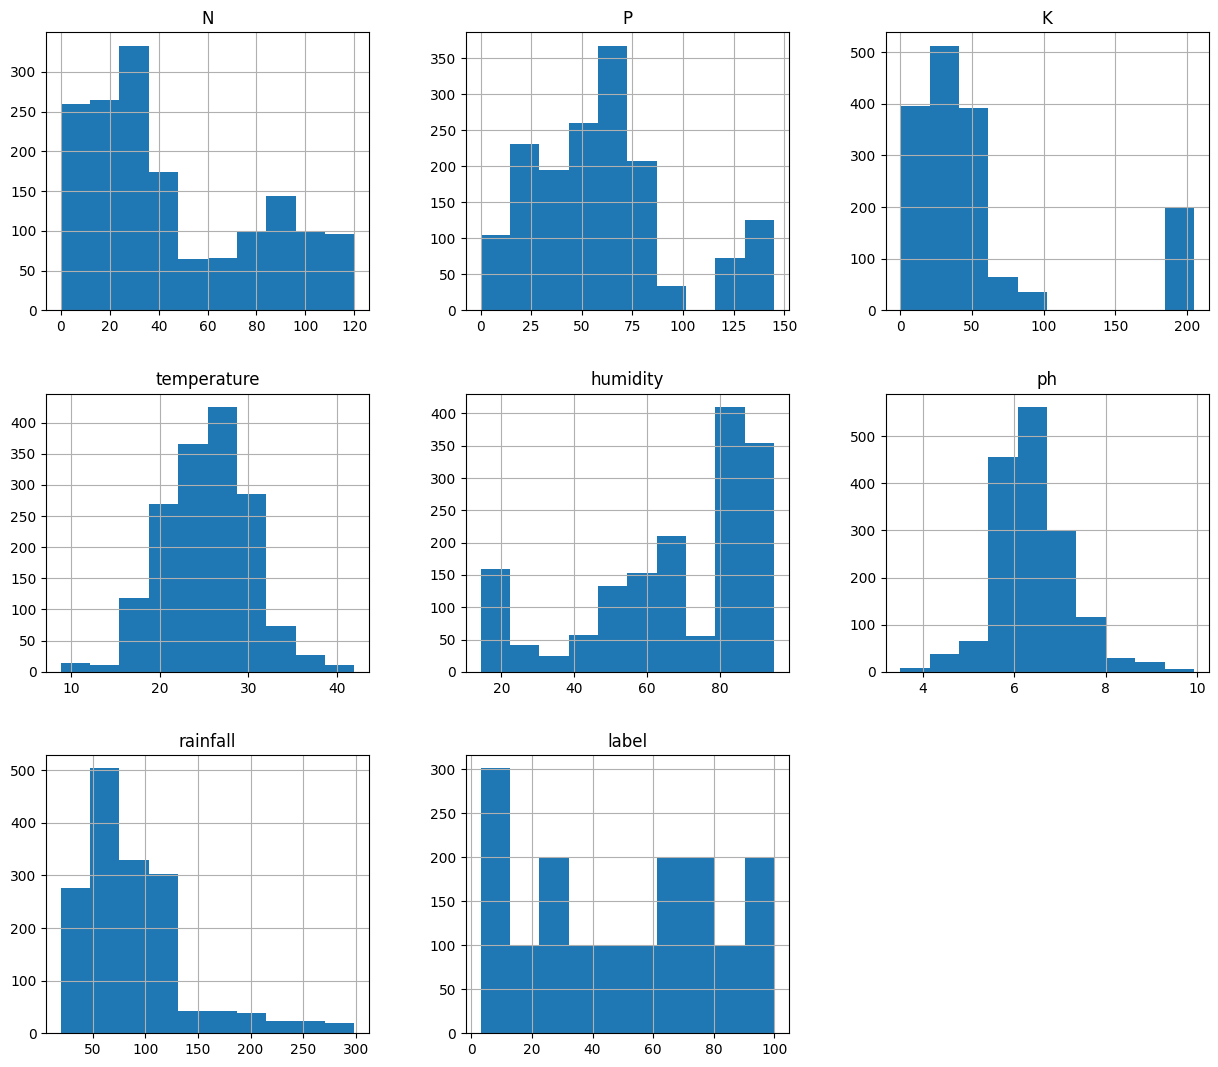

In [24]:
df.hist(bins = 10 , figsize = (15,13))
plt.show()

<Axes: >

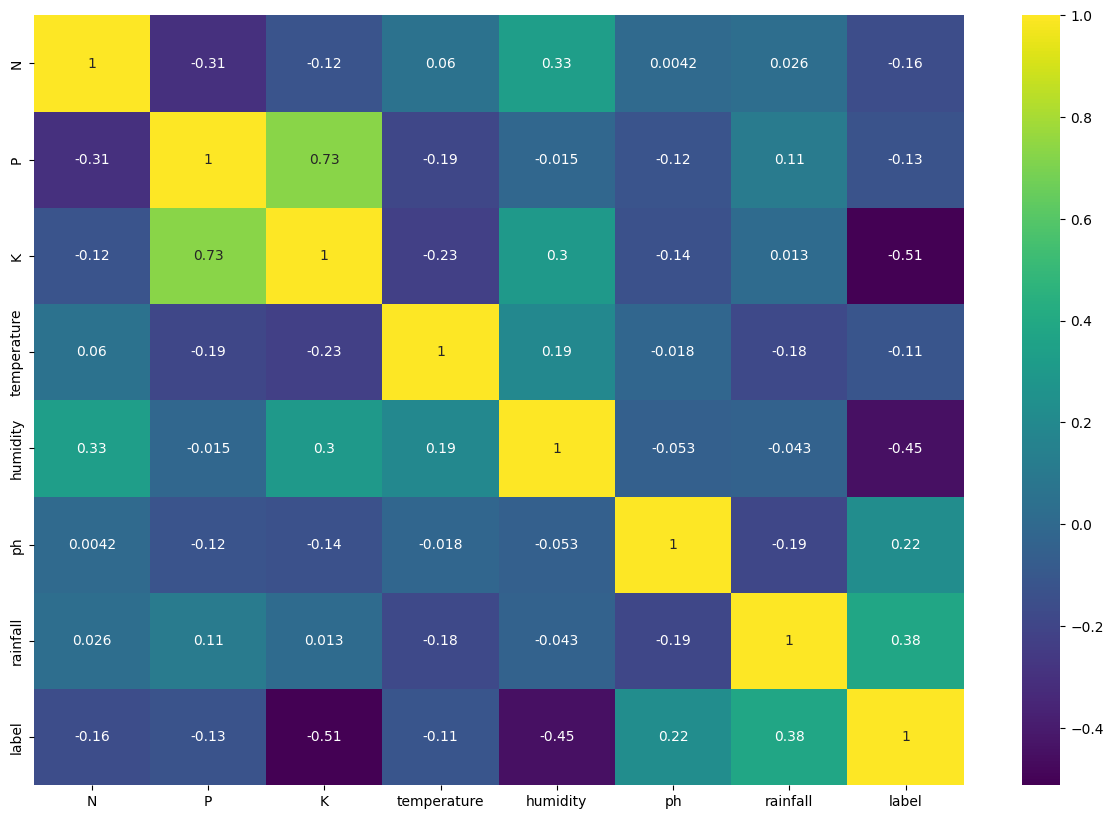

In [25]:
plt.figure(figsize = (15,10))
correlation = df.corr()
sns.heatmap(correlation , annot = True , cmap = 'viridis')

<Axes: xlabel='label', ylabel='count'>

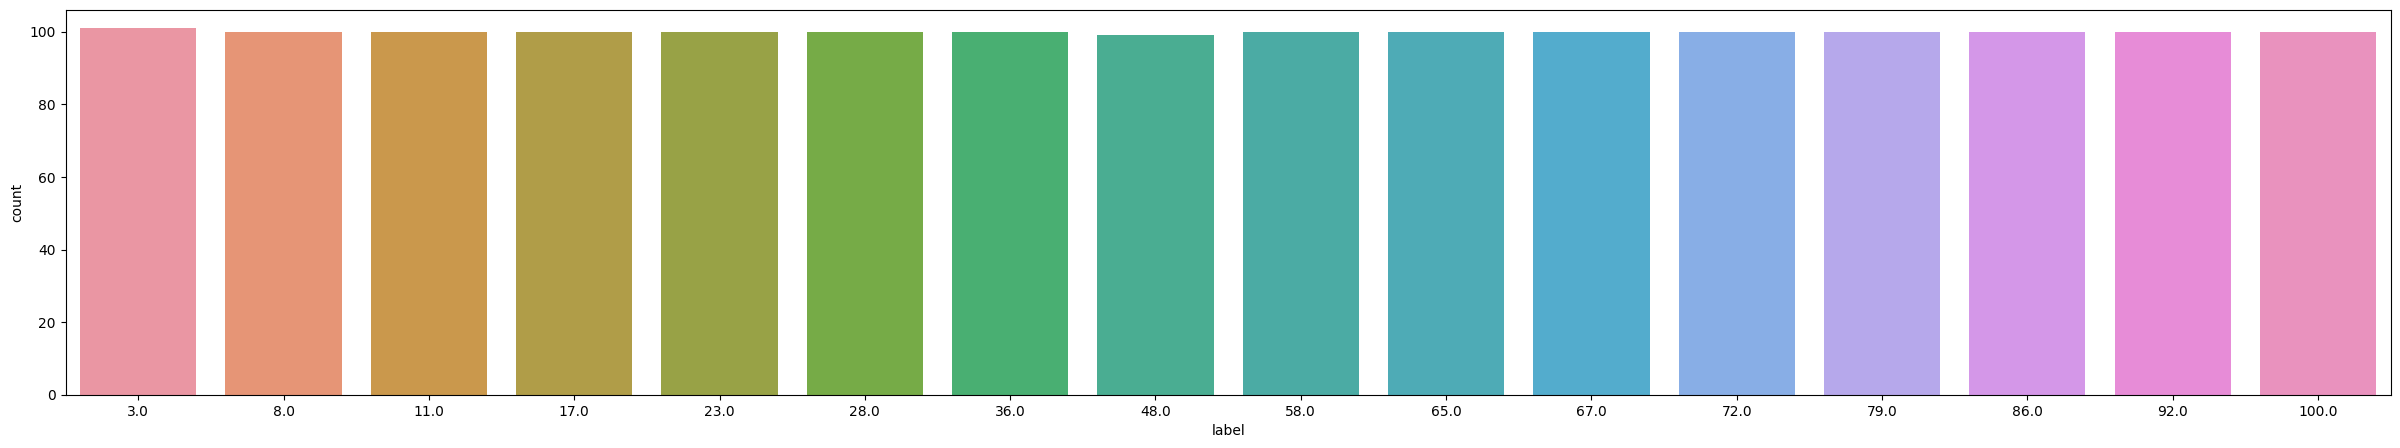

In [26]:
plt.figure(figsize = (30 , 5))
sns.countplot(data = df , x = 'label' )

<Axes: xlabel='label', ylabel='N'>

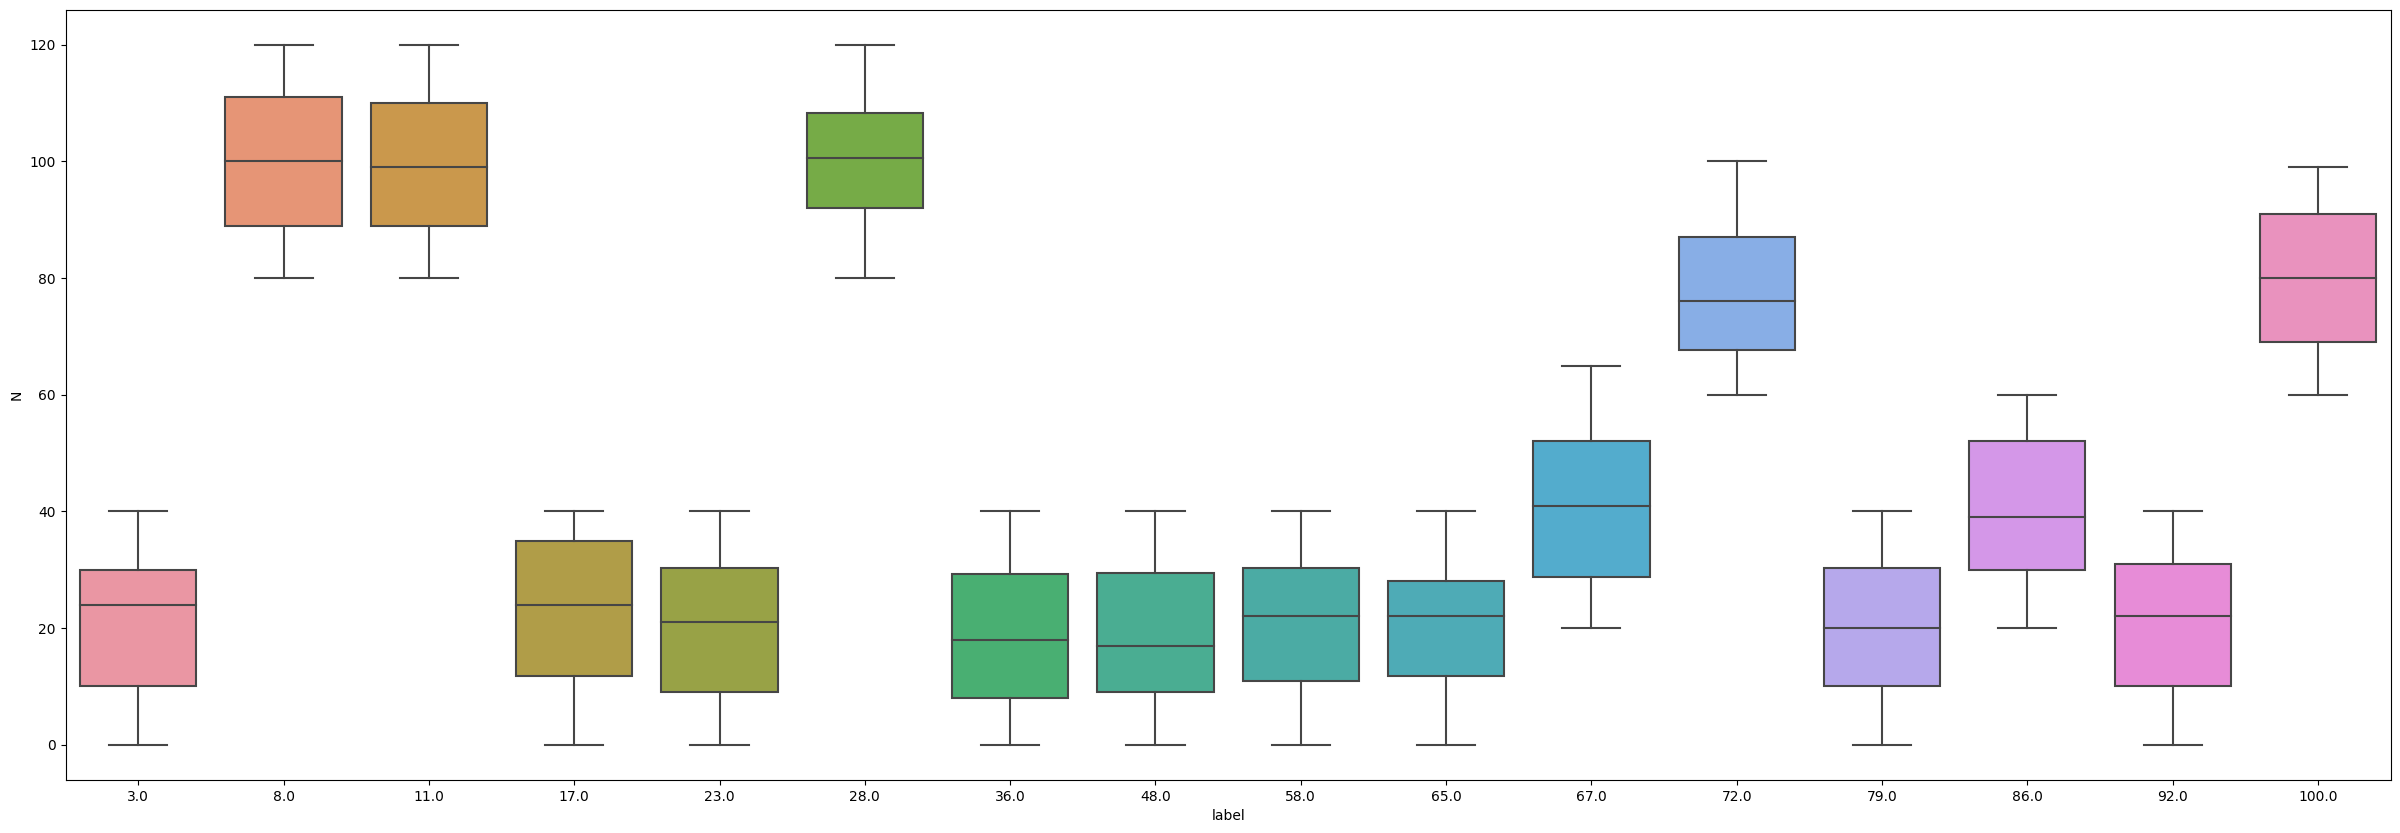

In [27]:
plt.figure(figsize = (30 , 10))
sns.boxplot(data = df , x = 'label' , y = 'N')

<Axes: xlabel='label', ylabel='P'>

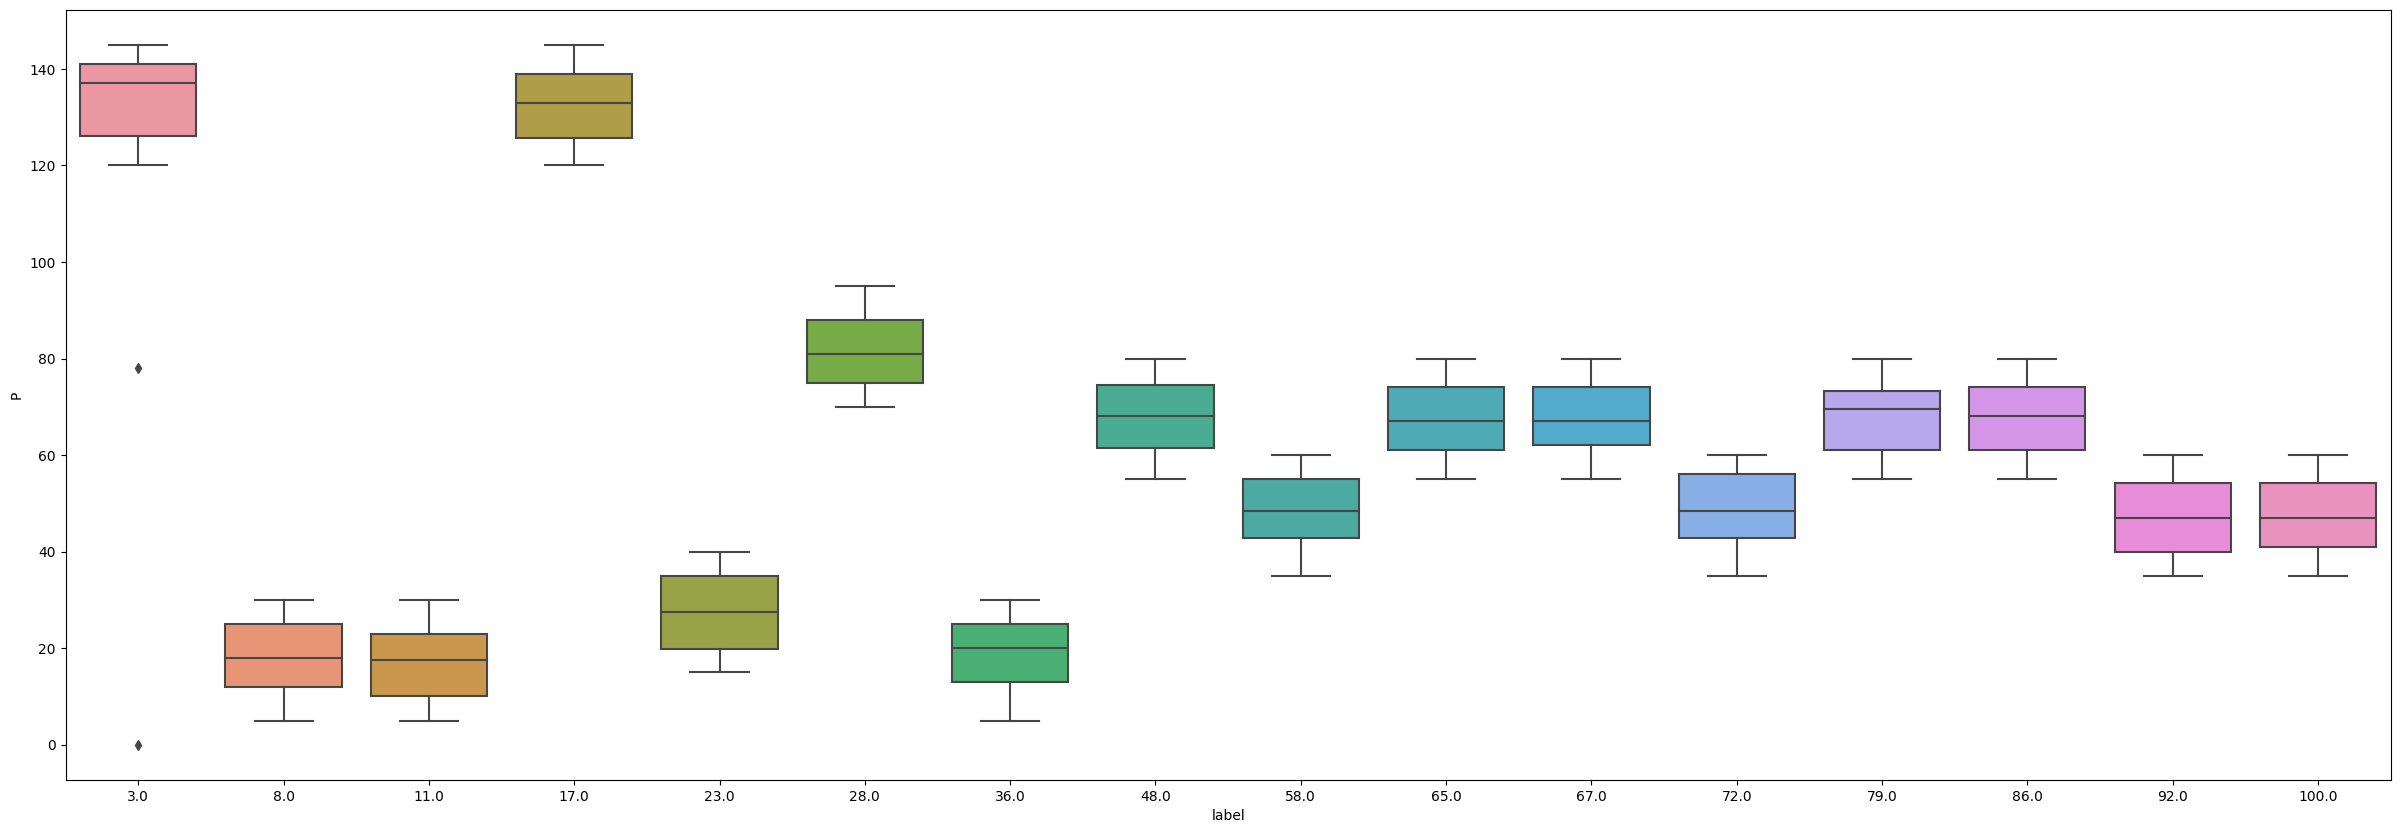

In [28]:
plt.figure(figsize = (30 , 10))
sns.boxplot(data = df , x = 'label' , y = 'P')

<Axes: xlabel='label', ylabel='K'>

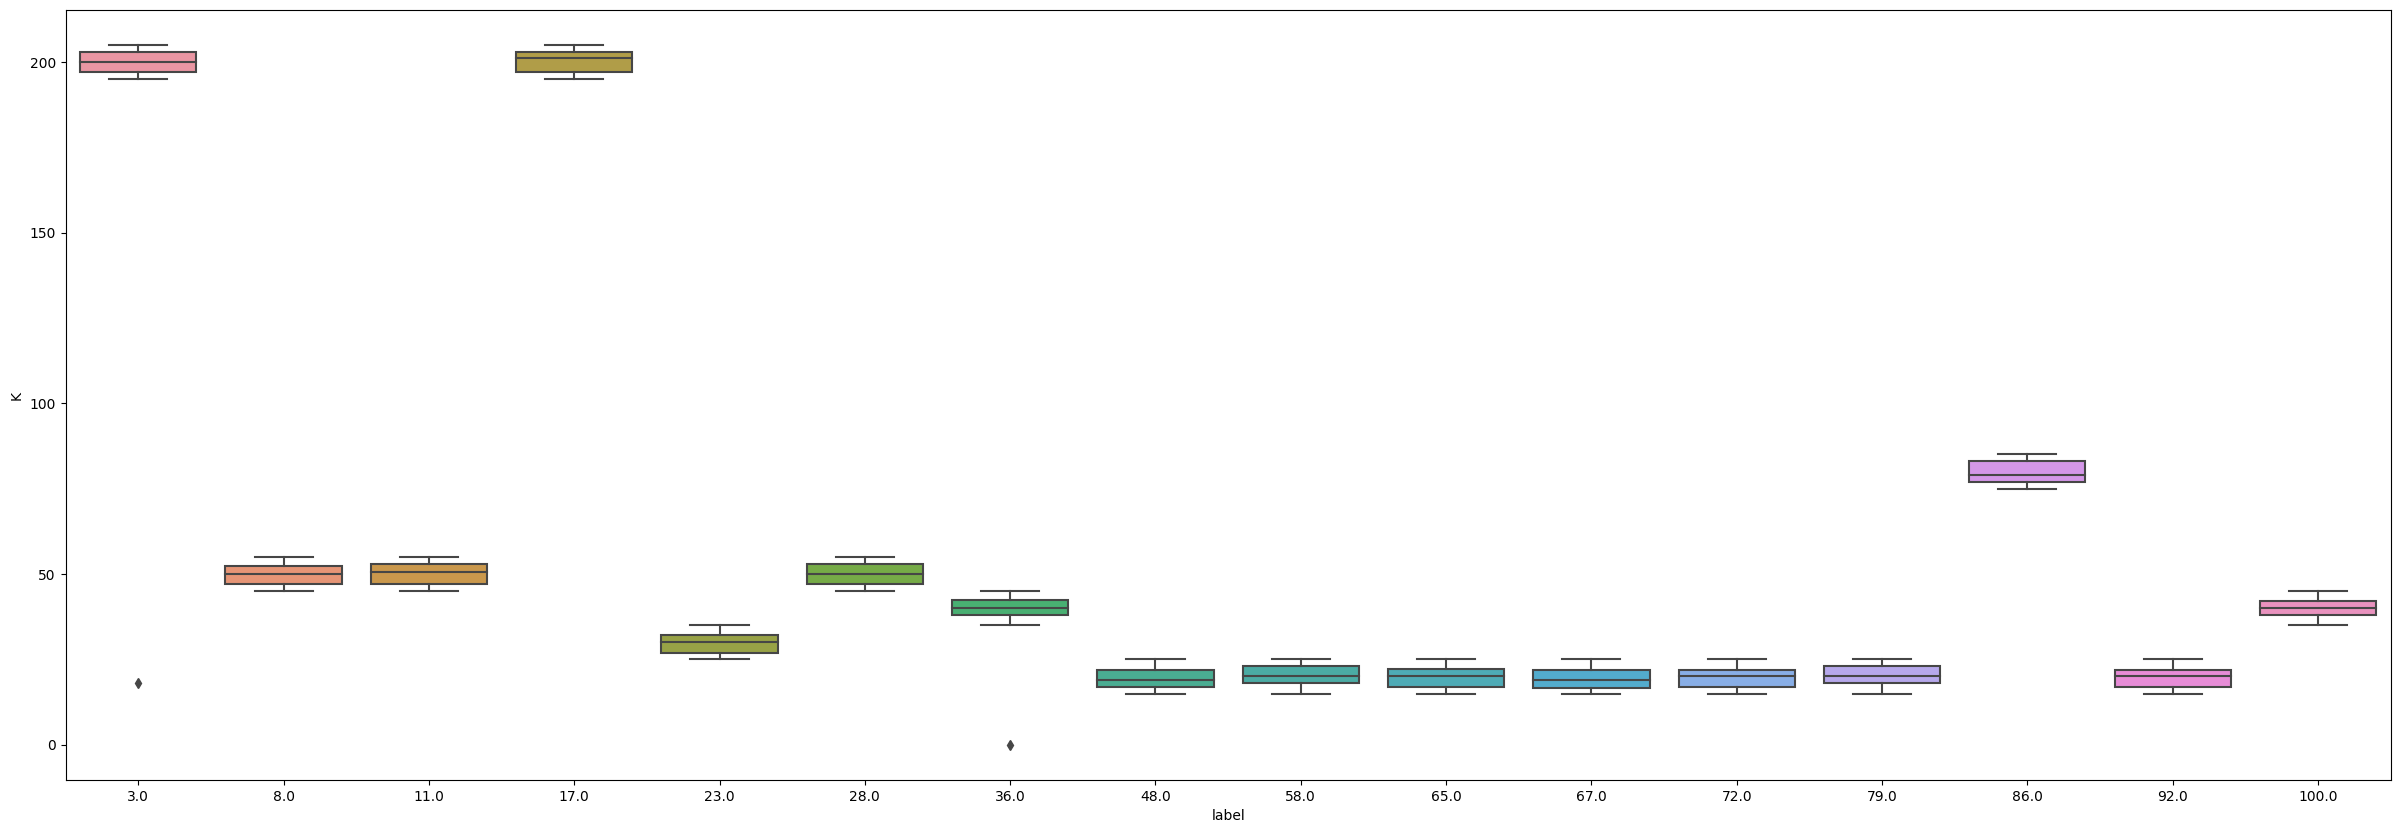

In [29]:
plt.figure(figsize = (30 , 10))
sns.boxplot(data = df , x = 'label' , y = 'K')

<Axes: xlabel='label', ylabel='temperature'>

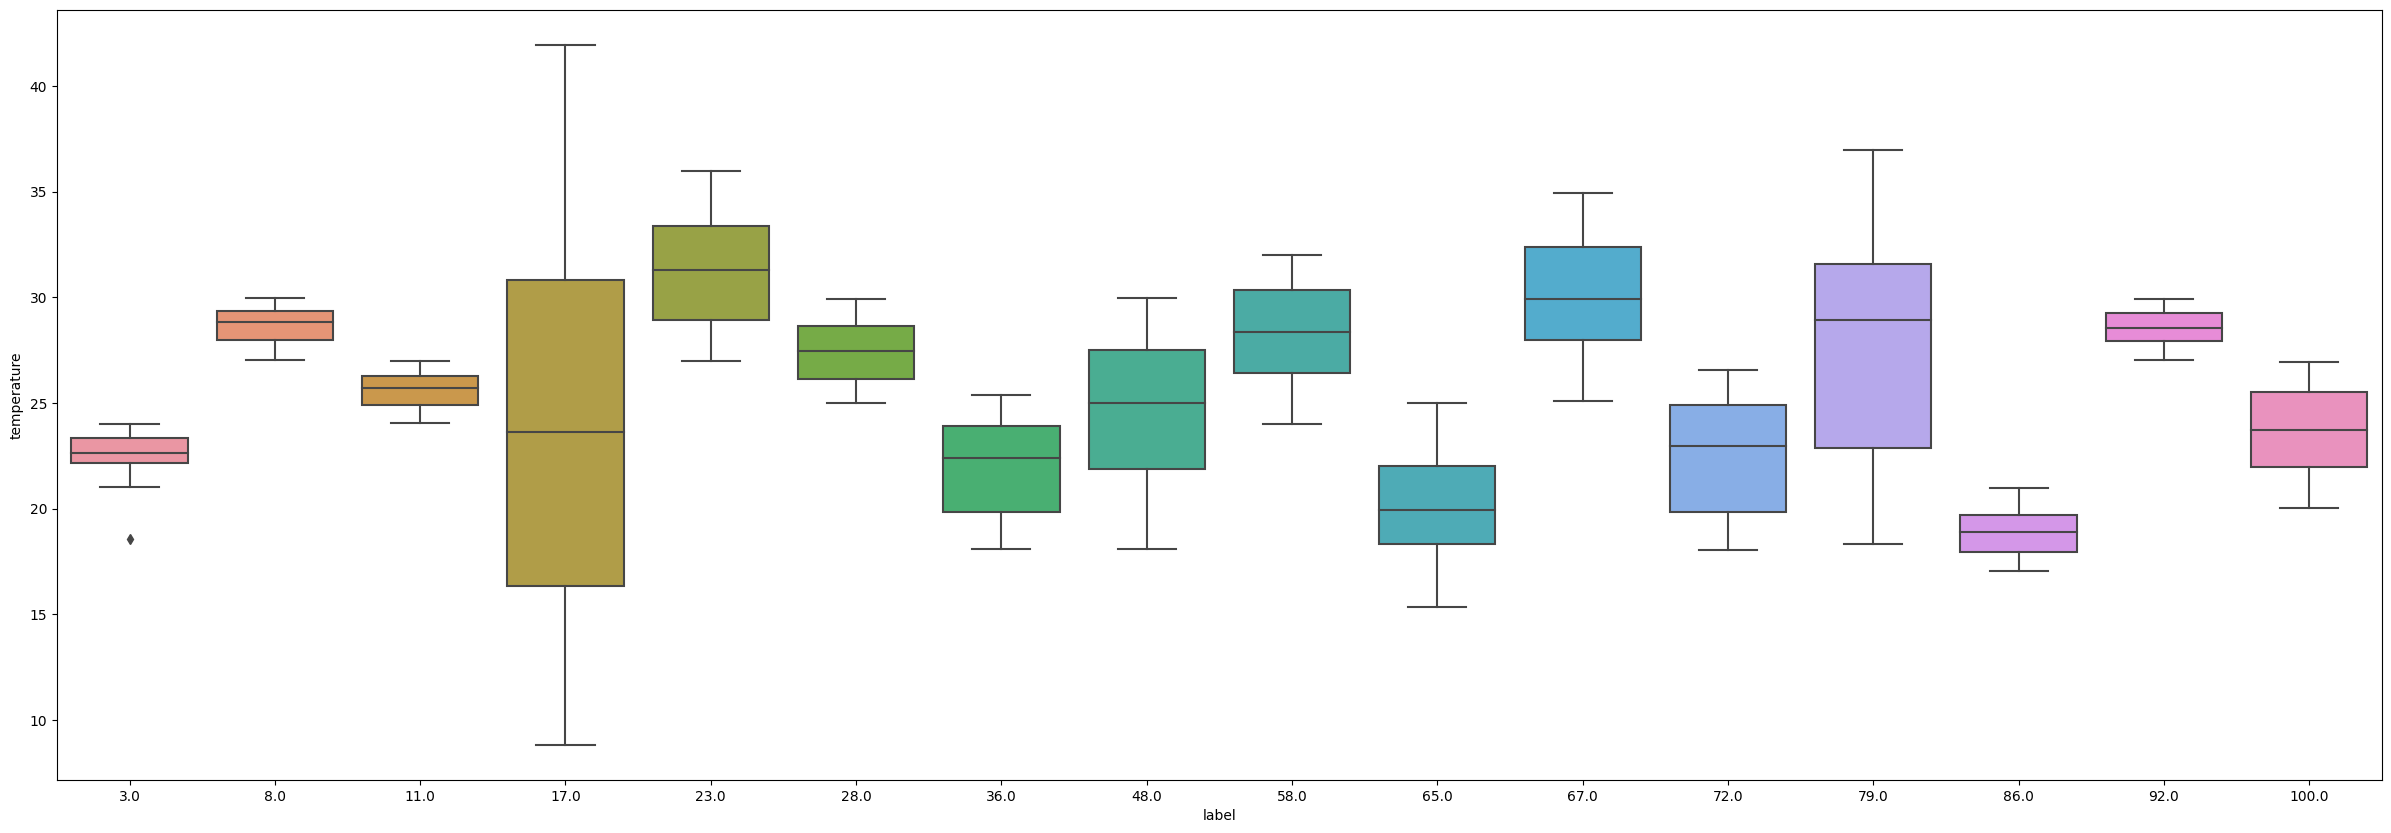

In [30]:
plt.figure(figsize = (30 , 10))
sns.boxplot(data = df , x = 'label' , y = 'temperature')

<Axes: xlabel='label', ylabel='humidity'>

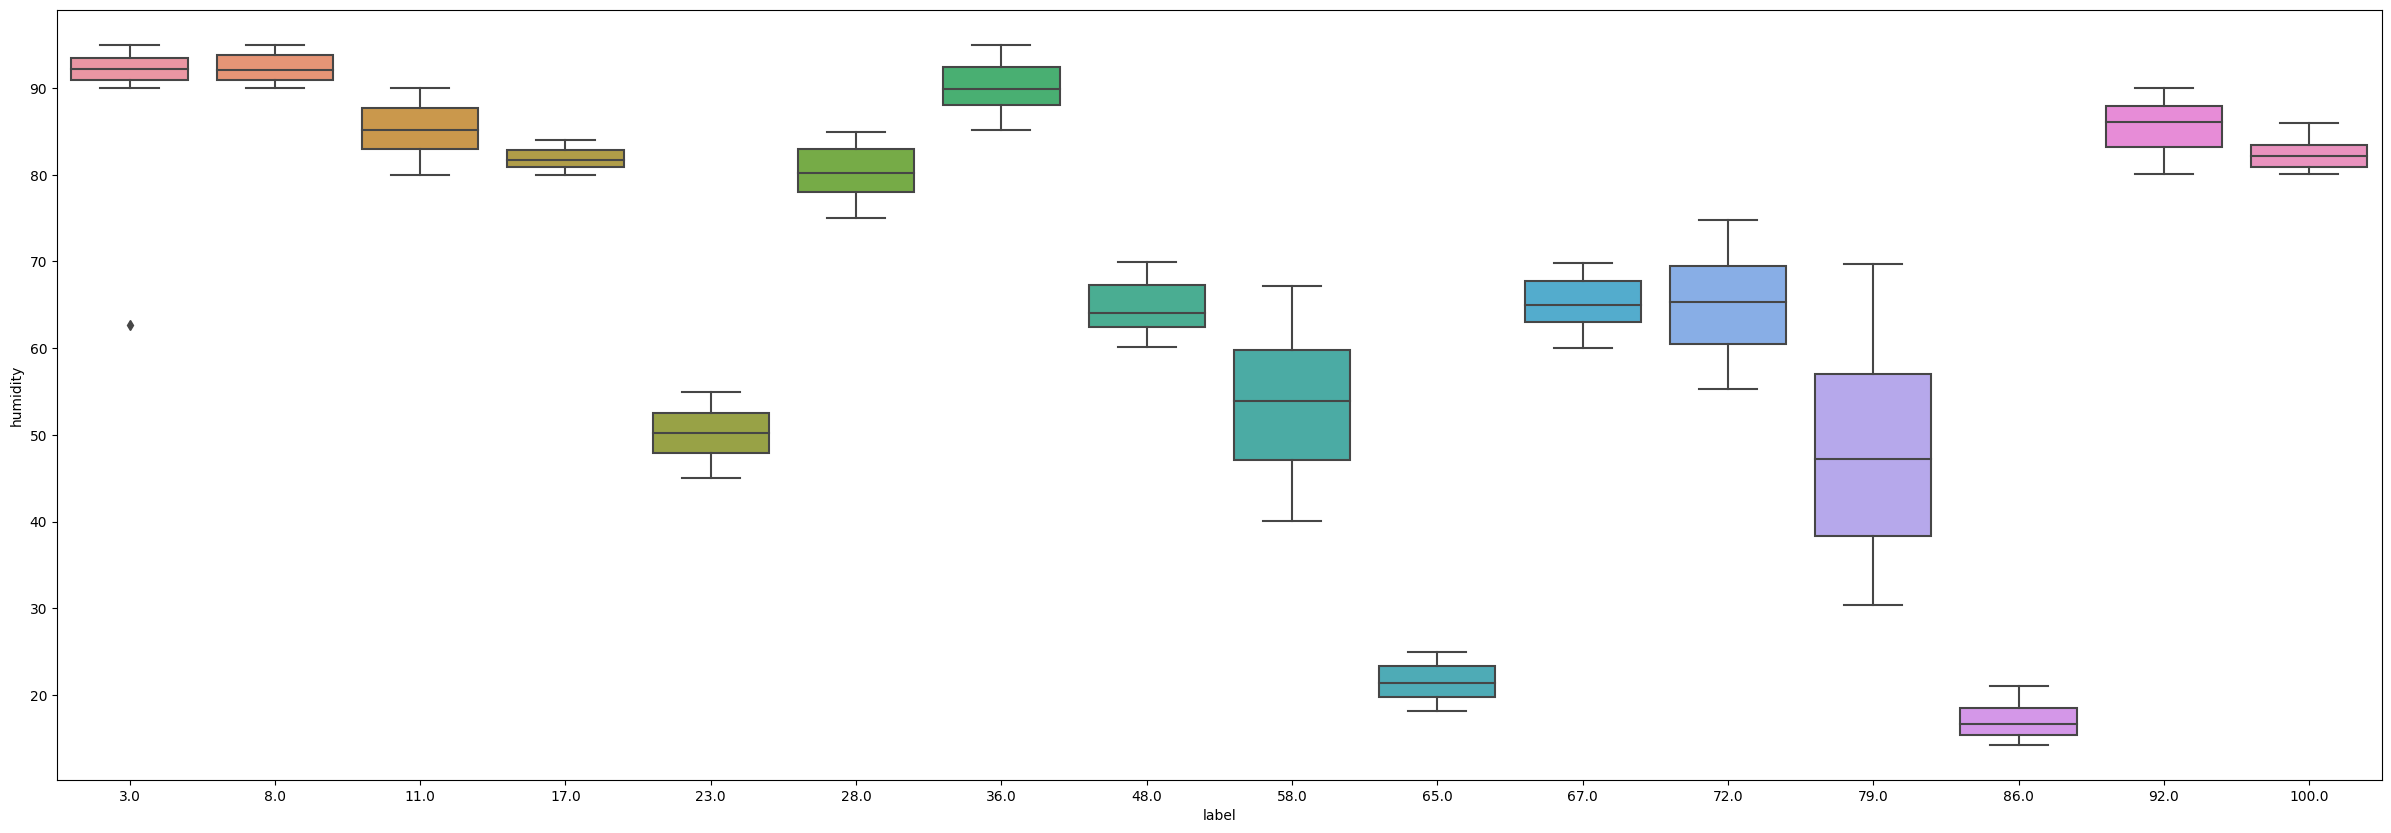

In [31]:
plt.figure(figsize = (30 , 10))
sns.boxplot(data = df , x = 'label' , y = 'humidity')

<Axes: xlabel='label', ylabel='ph'>

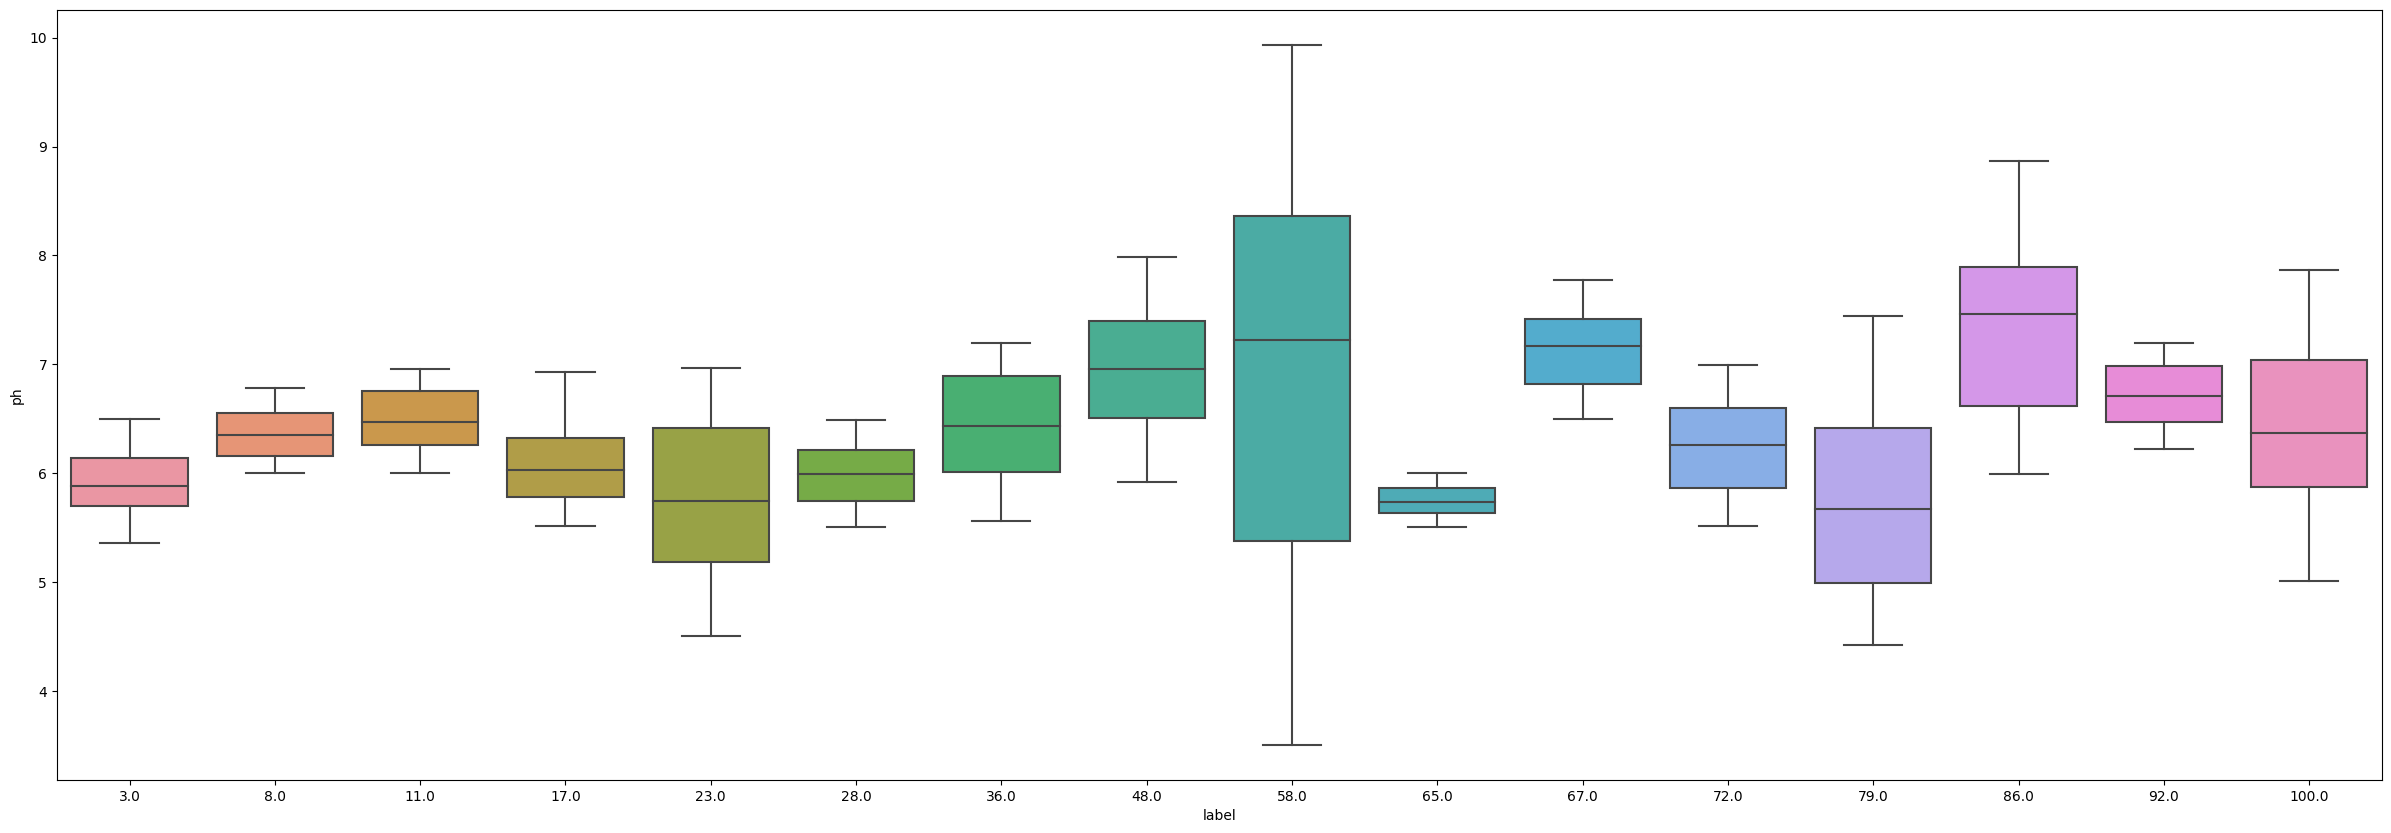

In [32]:
plt.figure(figsize = (30 , 10))
sns.boxplot(data = df , x = 'label' , y = 'ph')

<Axes: xlabel='label', ylabel='rainfall'>

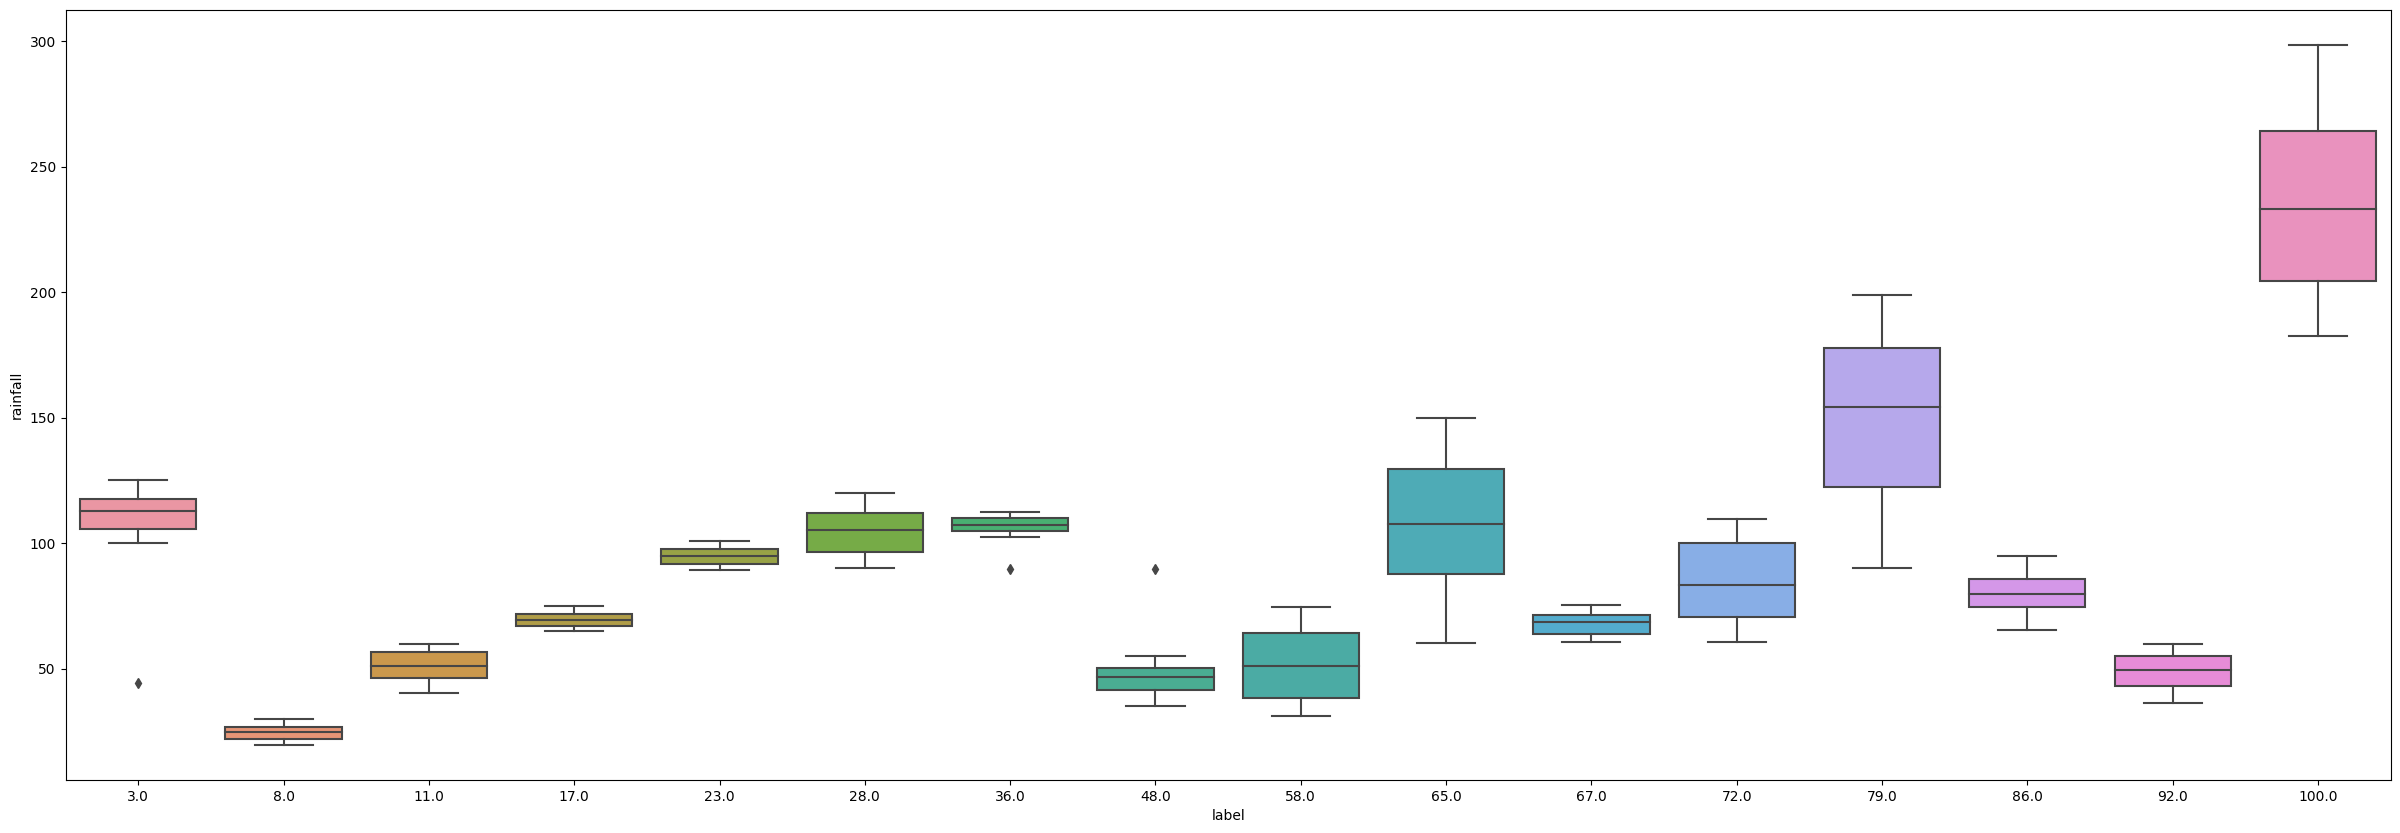

In [33]:
plt.figure(figsize = (30 , 10))
sns.boxplot(data = df , x = 'label' , y = 'rainfall')

In [34]:
fig = px.histogram(df , x ='N', marginal = 'violin')
fig.update_traces(opacity = 0.85)
fig.show()

fig = px.histogram(df , x ='P', marginal = 'violin')
fig.update_traces(opacity = 0.85)
fig.show()

fig = px.histogram(df , x ='K', marginal = 'violin')
fig.update_traces(opacity = 0.85)
fig.show()

fig = px.histogram(df , x ='temperature', marginal = 'violin')
fig.update_traces(opacity = 0.85)
fig.show()

fig = px.histogram(df , x ='humidity', marginal = 'violin')
fig.update_traces(opacity = 0.85)
fig.show()

fig = px.histogram(df , x ='ph', marginal = 'violin')
fig.update_traces(opacity = 0.85)
fig.show()

fig = px.histogram(df , x ='rainfall', marginal = 'violin')
fig.update_traces(opacity = 0.85)
fig.show()

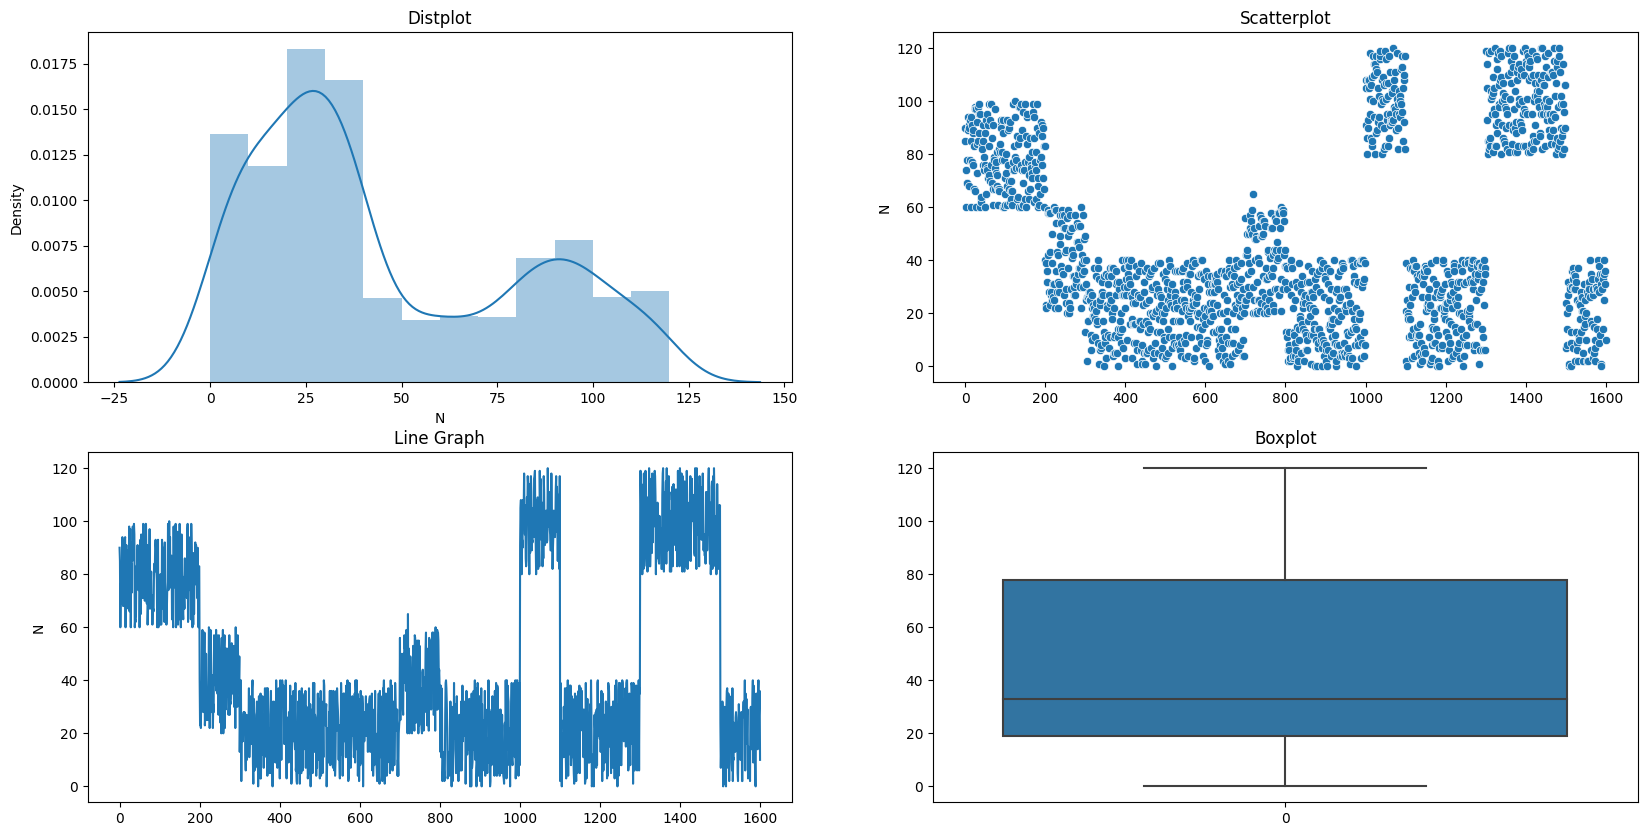

In [35]:
fig = plt.figure(figsize=(20,10))

#1
plt.subplot(2,2,1)
plt.title('Distplot')
sns.distplot(df.N)

#2
plt.subplot(2,2,2)
plt.title('Scatterplot')
sns.scatterplot(data = df,x = df.index,y = df.N )

#3
plt.subplot(2,2,3)
plt.title('Line Graph')
sns.lineplot(data = df, x = df.index,y = df.N)

#4
plt.subplot(2,2,4)
plt.title('Boxplot')
sns.boxplot(data = df['N'])

plt.show()

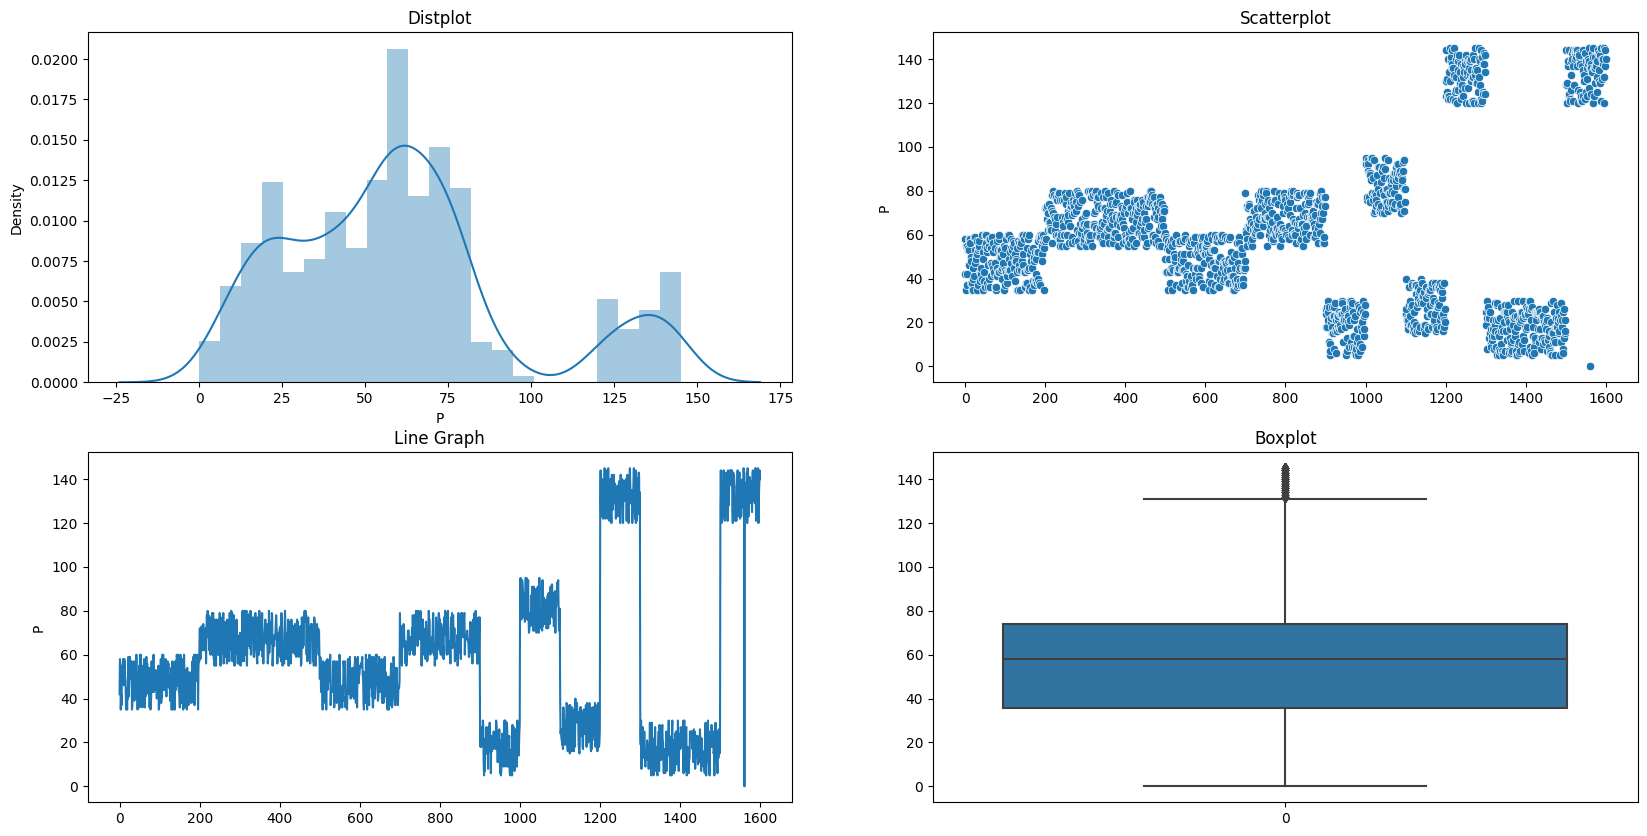

In [36]:
fig = plt.figure(figsize=(20,10))

#1
plt.subplot(2,2,1)
plt.title('Distplot')
sns.distplot(df.P)

#2
plt.subplot(2,2,2)
plt.title('Scatterplot')
sns.scatterplot(data = df,x = df.index,y = df.P)

#3
plt.subplot(2,2,3)
plt.title('Line Graph')
sns.lineplot(data = df, x = df.index,y = df.P)

#4
plt.subplot(2,2,4)
plt.title('Boxplot')
sns.boxplot(data = df['P'])

plt.show()

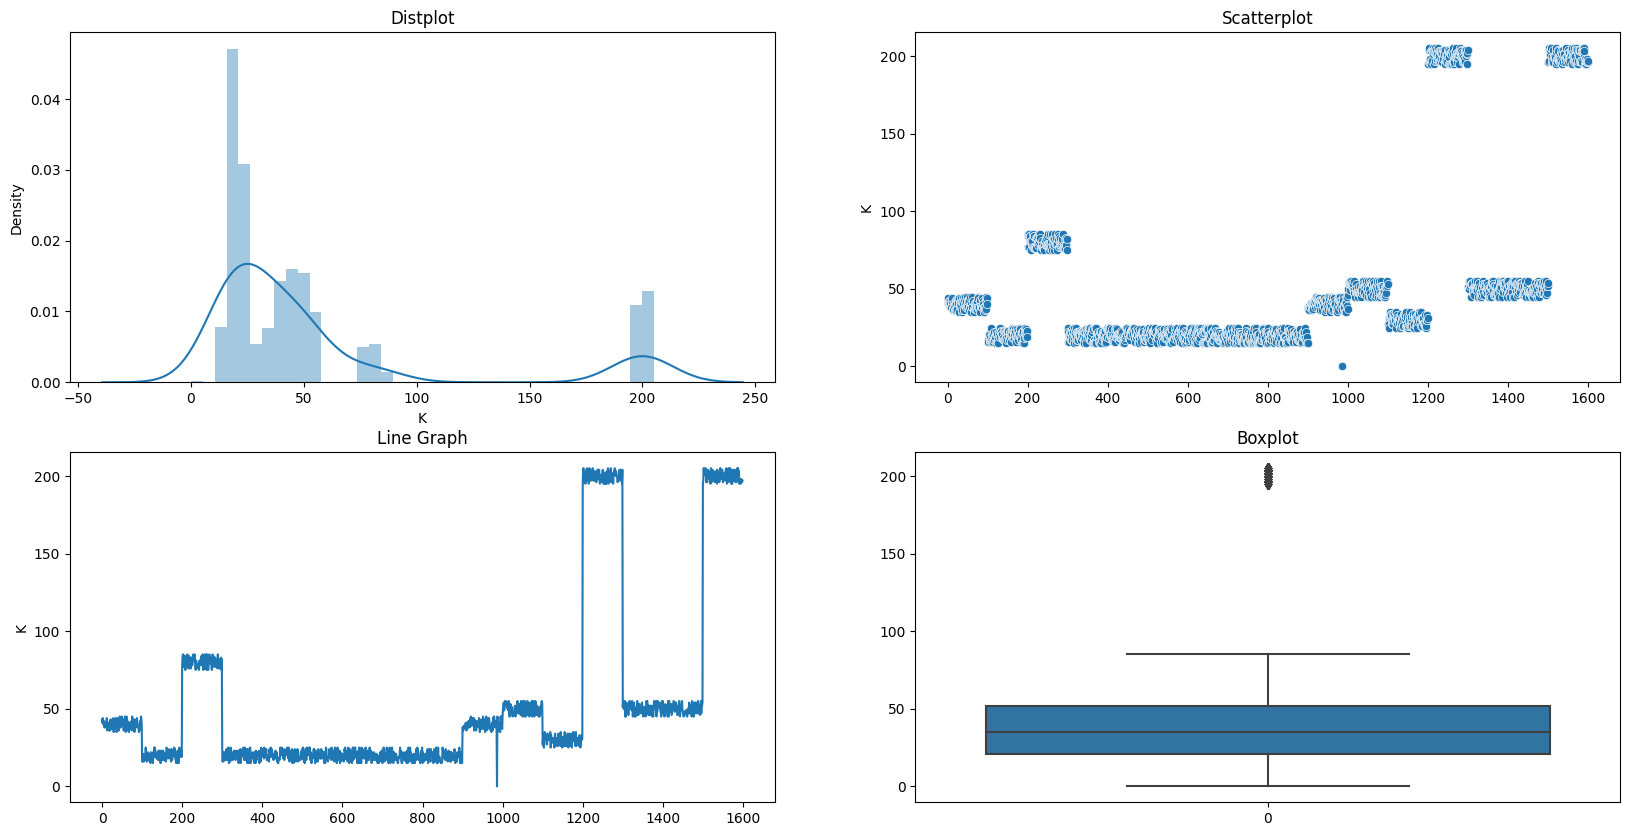

In [37]:
fig = plt.figure(figsize=(20,10))

#1
plt.subplot(2,2,1)
plt.title('Distplot')
sns.distplot(df.K)

#2
plt.subplot(2,2,2)
plt.title('Scatterplot')
sns.scatterplot(data = df,x = df.index,y = df.K)

#3
plt.subplot(2,2,3)
plt.title('Line Graph')
sns.lineplot(data = df, x = df.index,y = df.K)

#4
plt.subplot(2,2,4)
plt.title('Boxplot')
sns.boxplot(data = df['K'])

plt.show()

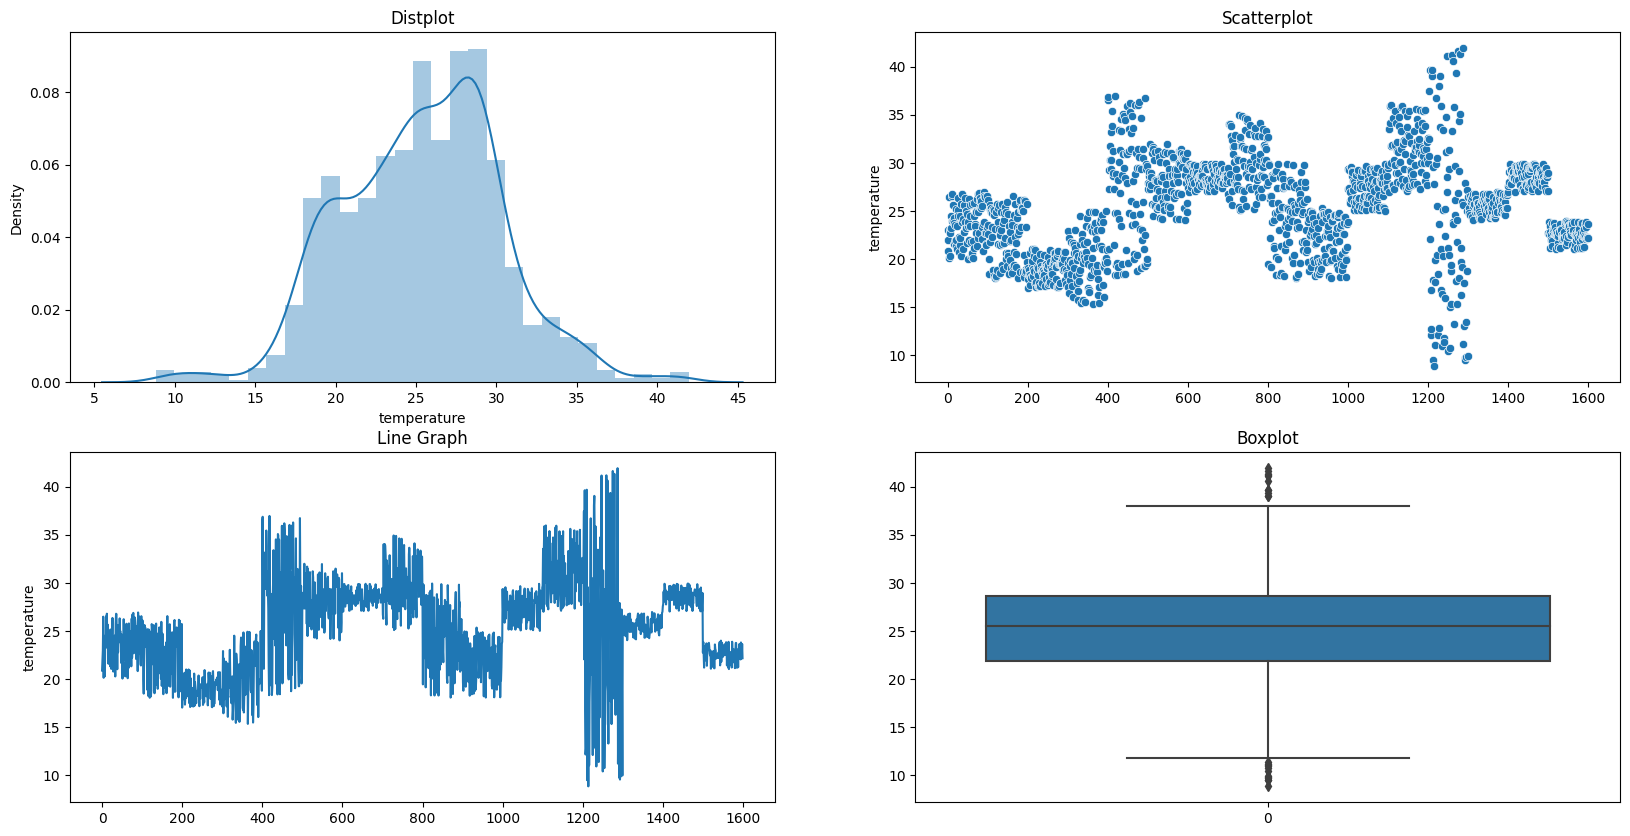

In [38]:
fig = plt.figure(figsize=(20,10))

#1
plt.subplot(2,2,1)
plt.title('Distplot')
sns.distplot(df.temperature)

#2
plt.subplot(2,2,2)
plt.title('Scatterplot')
sns.scatterplot(data = df,x = df.index,y = df.temperature)

#3
plt.subplot(2,2,3)
plt.title('Line Graph')
sns.lineplot(data = df, x = df.index,y = df.temperature)

#4
plt.subplot(2,2,4)
plt.title('Boxplot')
sns.boxplot(data = df['temperature'])

plt.show()

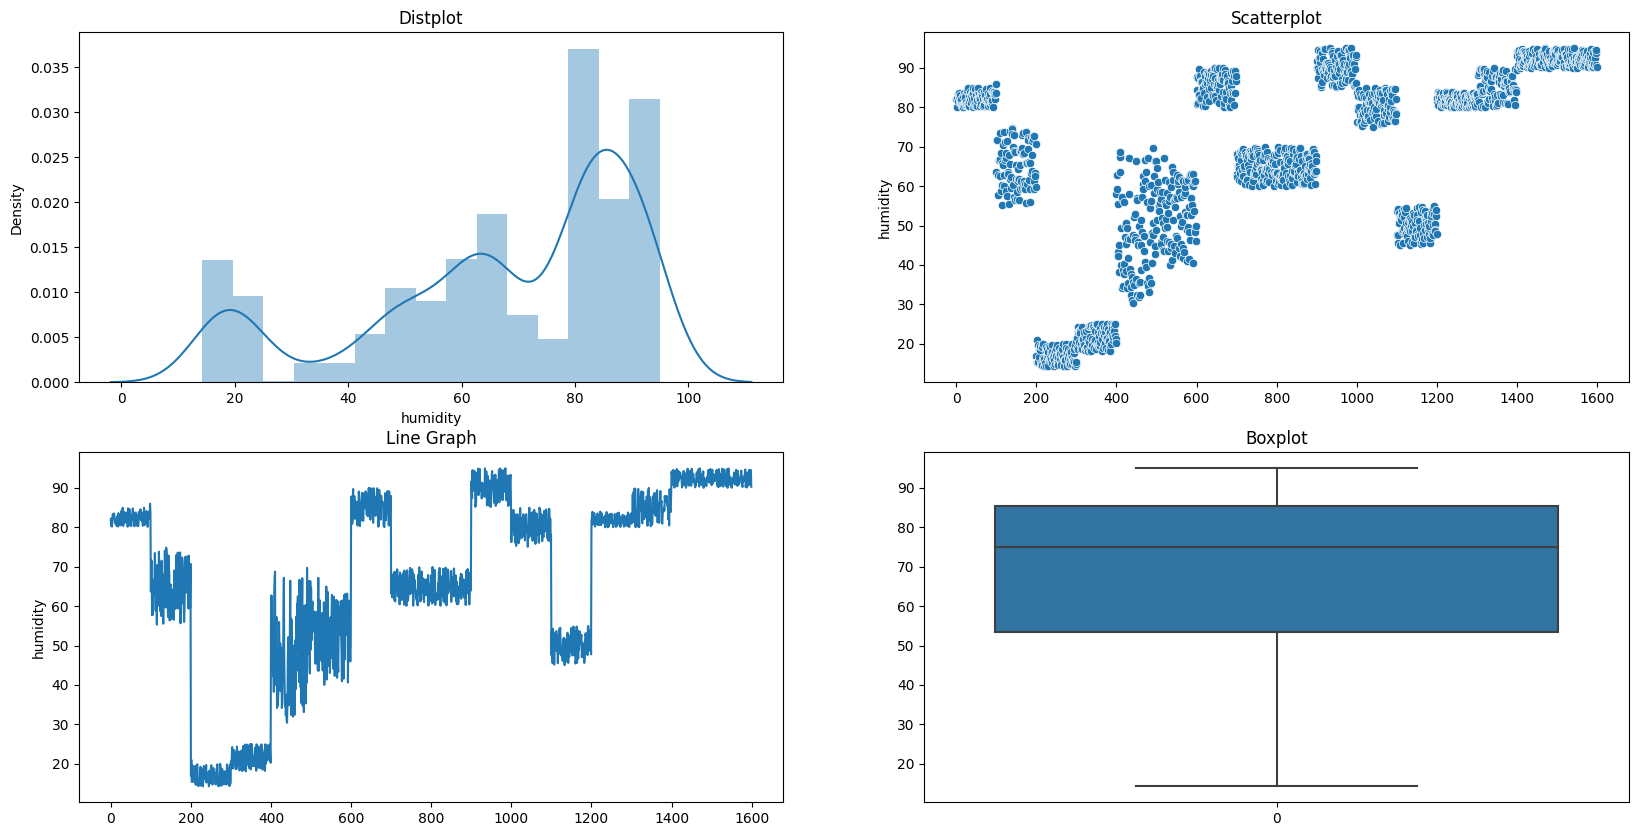

In [39]:
fig = plt.figure(figsize=(20,10))

#1
plt.subplot(2,2,1)
plt.title('Distplot')
sns.distplot(df.humidity)

#2
plt.subplot(2,2,2)
plt.title('Scatterplot')
sns.scatterplot(data = df,x = df.index,y = df.humidity)

#3
plt.subplot(2,2,3)
plt.title('Line Graph')
sns.lineplot(data = df, x = df.index,y = df.humidity)

#4
plt.subplot(2,2,4)
plt.title('Boxplot')
sns.boxplot(data = df['humidity'])

plt.show()

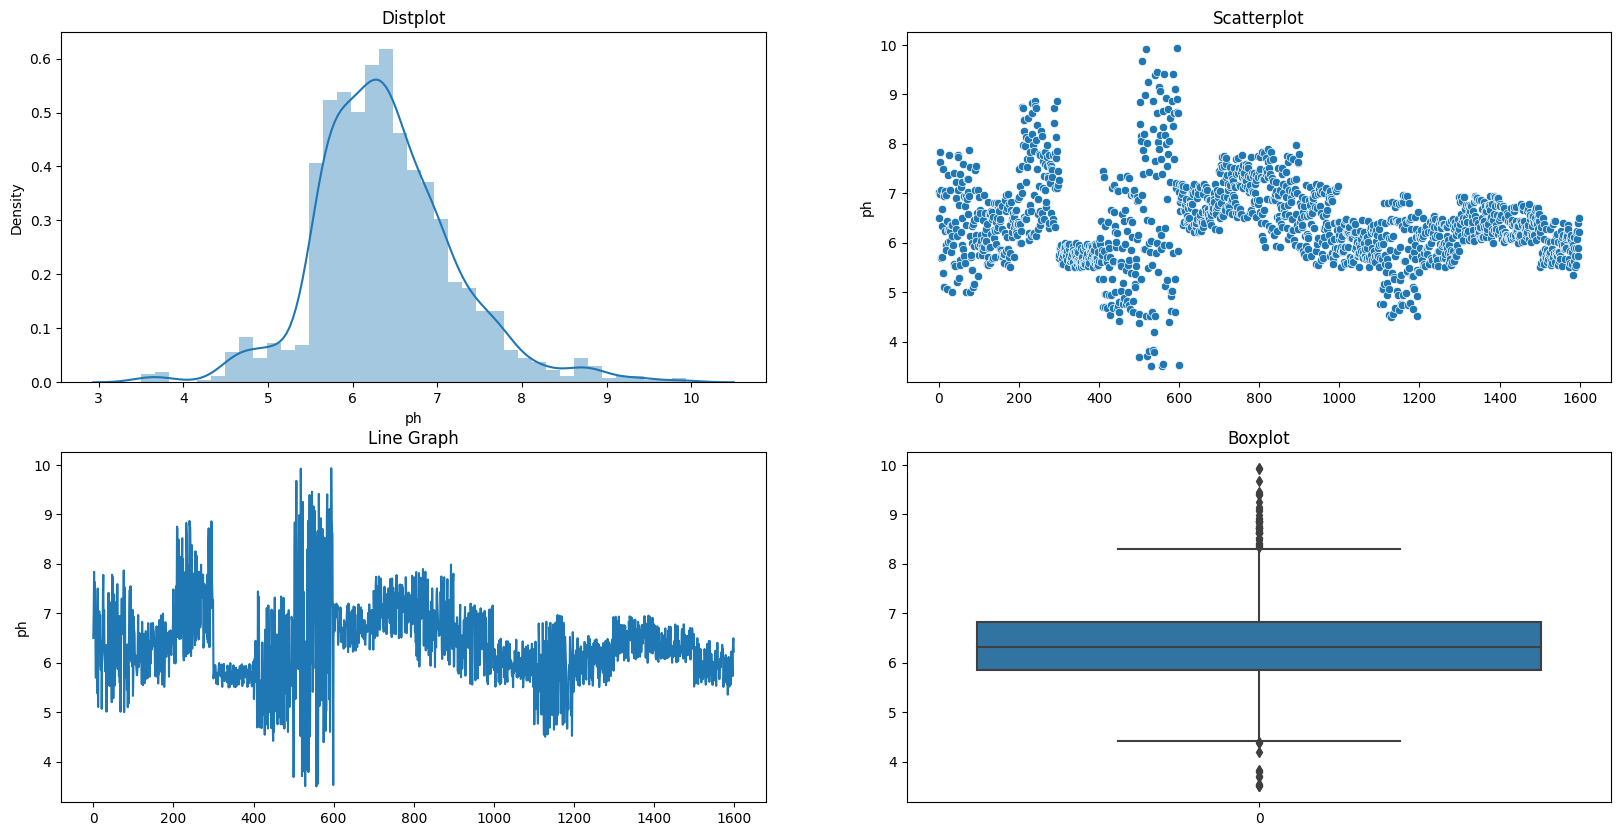

In [40]:
fig = plt.figure(figsize=(20,10))

#1
plt.subplot(2,2,1)
plt.title('Distplot')
sns.distplot(df.ph)

#2
plt.subplot(2,2,2)
plt.title('Scatterplot')
sns.scatterplot(data = df,x = df.index,y = df.ph)

#3
plt.subplot(2,2,3)
plt.title('Line Graph')
sns.lineplot(data = df, x = df.index,y = df.ph)

#4
plt.subplot(2,2,4)
plt.title('Boxplot')
sns.boxplot(data = df['ph'])

plt.show()

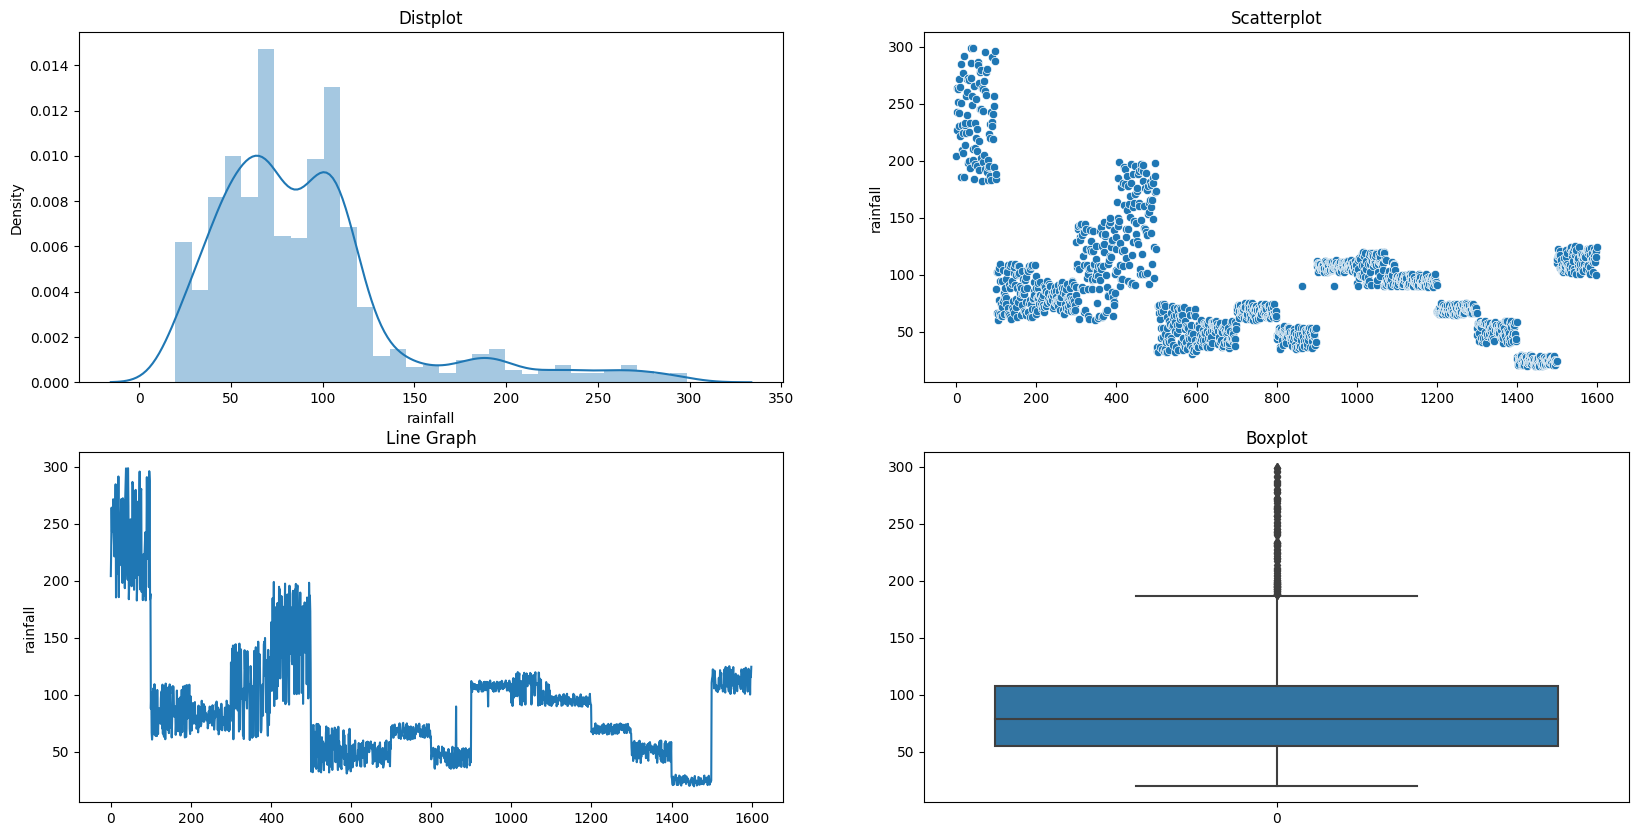

In [41]:
fig = plt.figure(figsize=(20,10))

#1
plt.subplot(2,2,1)
plt.title('Distplot')
sns.distplot(df.rainfall)

#2
plt.subplot(2,2,2)
plt.title('Scatterplot')
sns.scatterplot(data = df,x = df.index,y = df.rainfall)

#3
plt.subplot(2,2,3)
plt.title('Line Graph')
sns.lineplot(data = df, x = df.index,y = df.rainfall)

#4
plt.subplot(2,2,4)
plt.title('Boxplot')
sns.boxplot(data = df['rainfall'])

plt.show()

In [42]:
df1 = df.copy()
df1.drop('label',axis = 1,inplace = True)

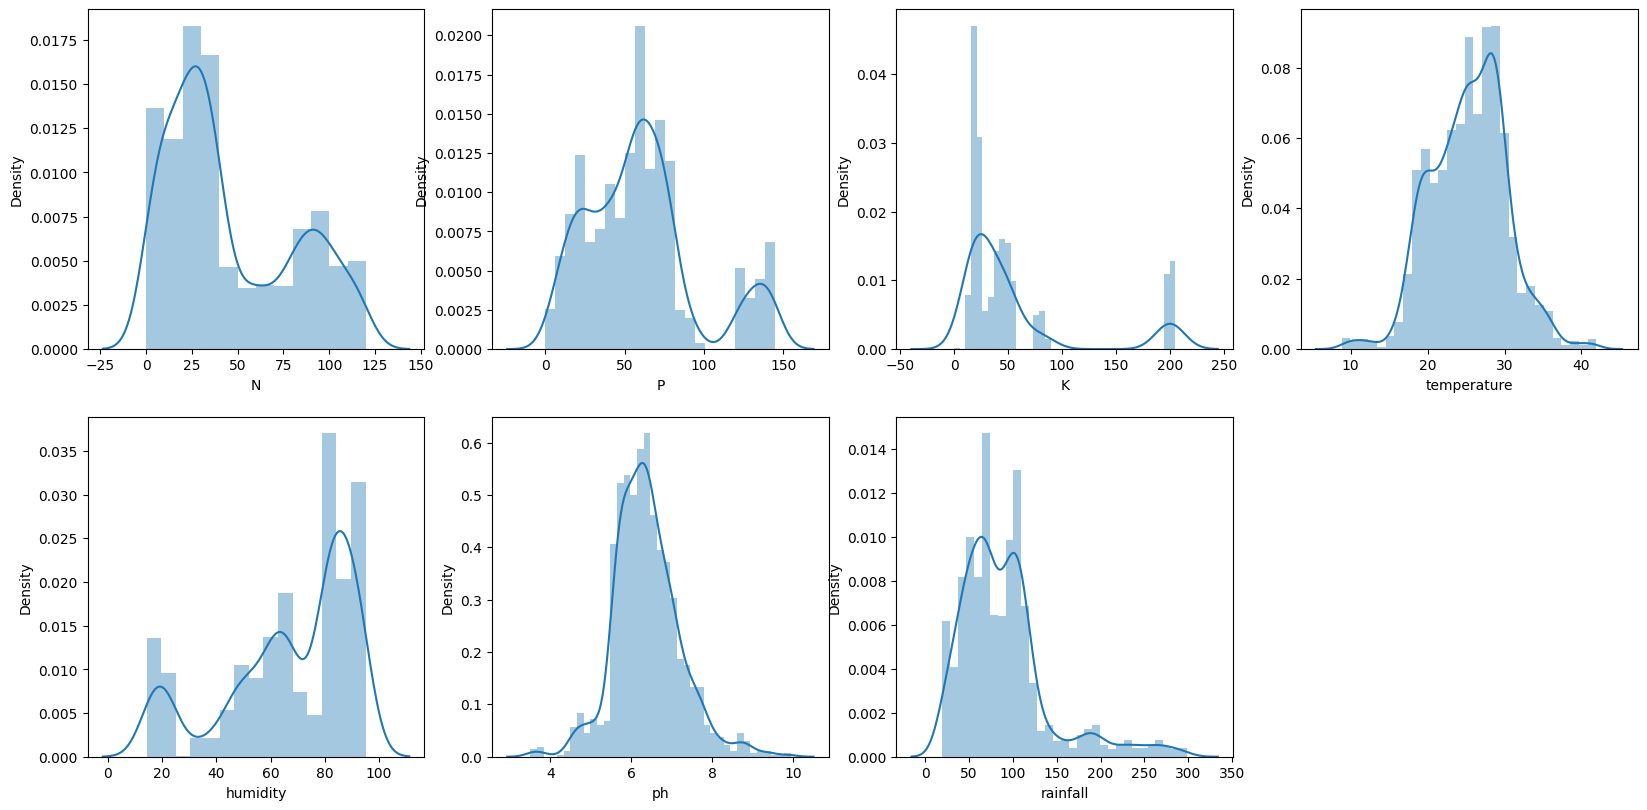

In [43]:
fig = plt.figure(figsize=(20,15))
for i,col in enumerate(df1.columns,1):
    plt.subplot(3,4,i)
    sns.distplot(df1[col])

plt.show()

### Categorizing the data to determine water scarcity

In [44]:
categor_condn = [(df['rainfall'] <= 150),
                  (df['rainfall'] > 250)]

rating = ['low','high']
df['Water Usage'] = np.select(categor_condn,rating,default = 'medium')

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,Water Usage
0,90,42.0,43.0,20.879744,82.002744,6.502985,203.983200,100.0,medium
1,85,58.0,41.0,22.000940,80.319644,7.038096,226.655537,100.0,medium
2,60,55.0,44.0,23.004459,82.320763,7.840207,263.964248,100.0,high
3,74,35.0,40.0,26.491096,80.158363,6.980401,242.864034,100.0,medium
4,78,42.0,42.0,20.130175,81.604873,7.628473,262.717340,100.0,high


In [45]:
df['Water Usage'].value_counts()

low       1448
medium     114
high        38
Name: Water Usage, dtype: int64

<Axes: ylabel='Water Usage'>

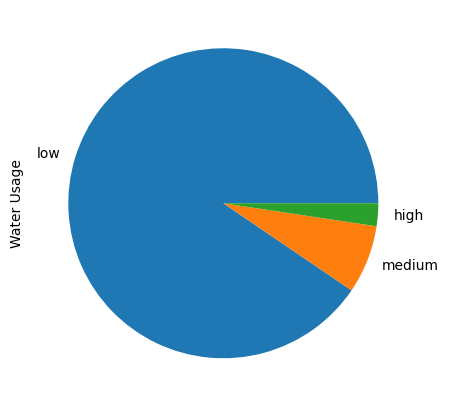

In [46]:
plt.figure(figsize = (5,8))
df['Water Usage'].value_counts().plot.pie()

<Axes: xlabel='Water Usage', ylabel='N'>

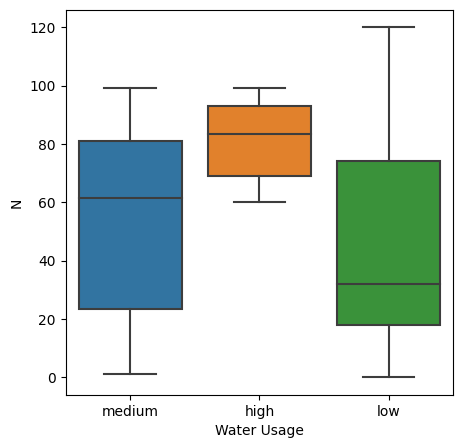

In [47]:
plt.figure(figsize = (5 , 5))
sns.boxplot(data = df , x = 'Water Usage' , y = 'N')

<Axes: xlabel='Water Usage', ylabel='P'>

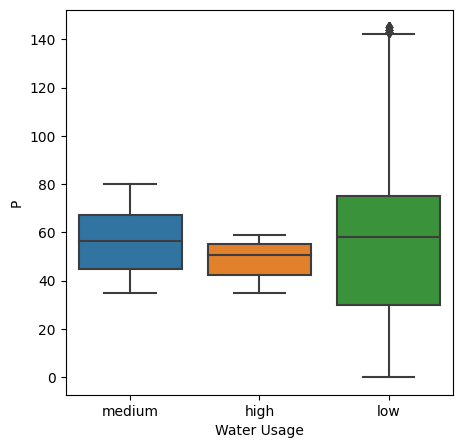

In [48]:
plt.figure(figsize = (5 , 5))
sns.boxplot(data = df , x = 'Water Usage' , y = 'P')

<Axes: xlabel='Water Usage', ylabel='K'>

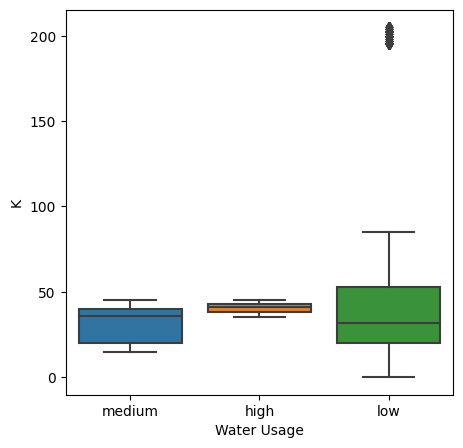

In [49]:
plt.figure(figsize = (5 , 5))
sns.boxplot(data = df , x = 'Water Usage' , y = 'K')

<Axes: xlabel='Water Usage', ylabel='temperature'>

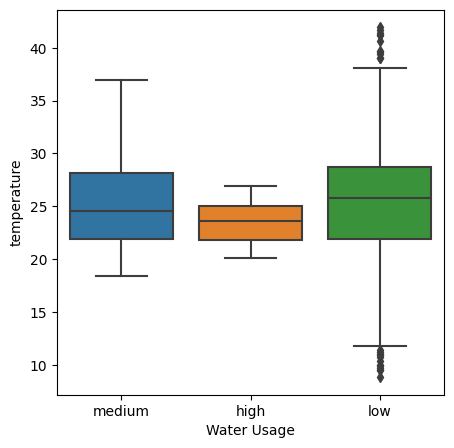

In [50]:
plt.figure(figsize = (5 , 5))
sns.boxplot(data = df , x = 'Water Usage' , y = 'temperature')

<Axes: xlabel='Water Usage', ylabel='humidity'>

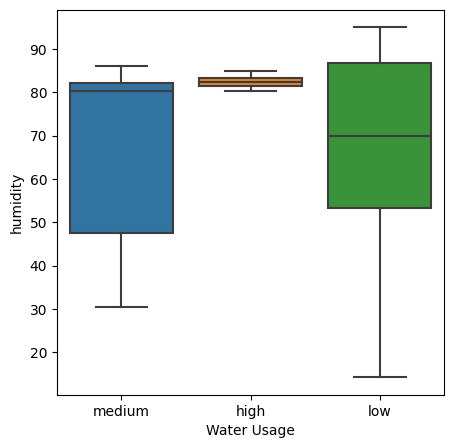

In [51]:
plt.figure(figsize = (5 , 5))
sns.boxplot(data = df , x = 'Water Usage' , y = 'humidity')

<Axes: xlabel='Water Usage', ylabel='ph'>

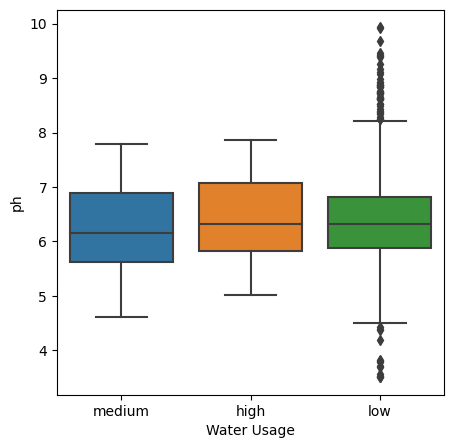

In [52]:
plt.figure(figsize = (5 , 5))
sns.boxplot(data = df , x = 'Water Usage' , y = 'ph')

<Axes: xlabel='Water Usage', ylabel='rainfall'>

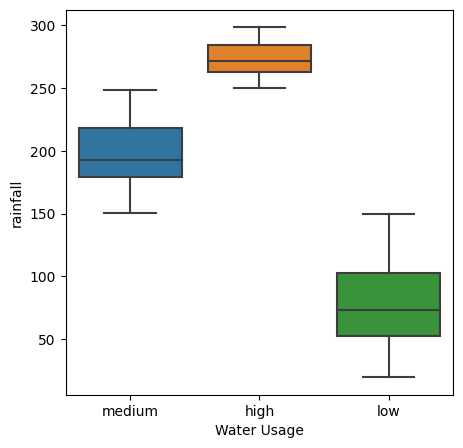

In [53]:
plt.figure(figsize = (5 , 5))
sns.boxplot(data = df , x = 'Water Usage' , y = 'rainfall')

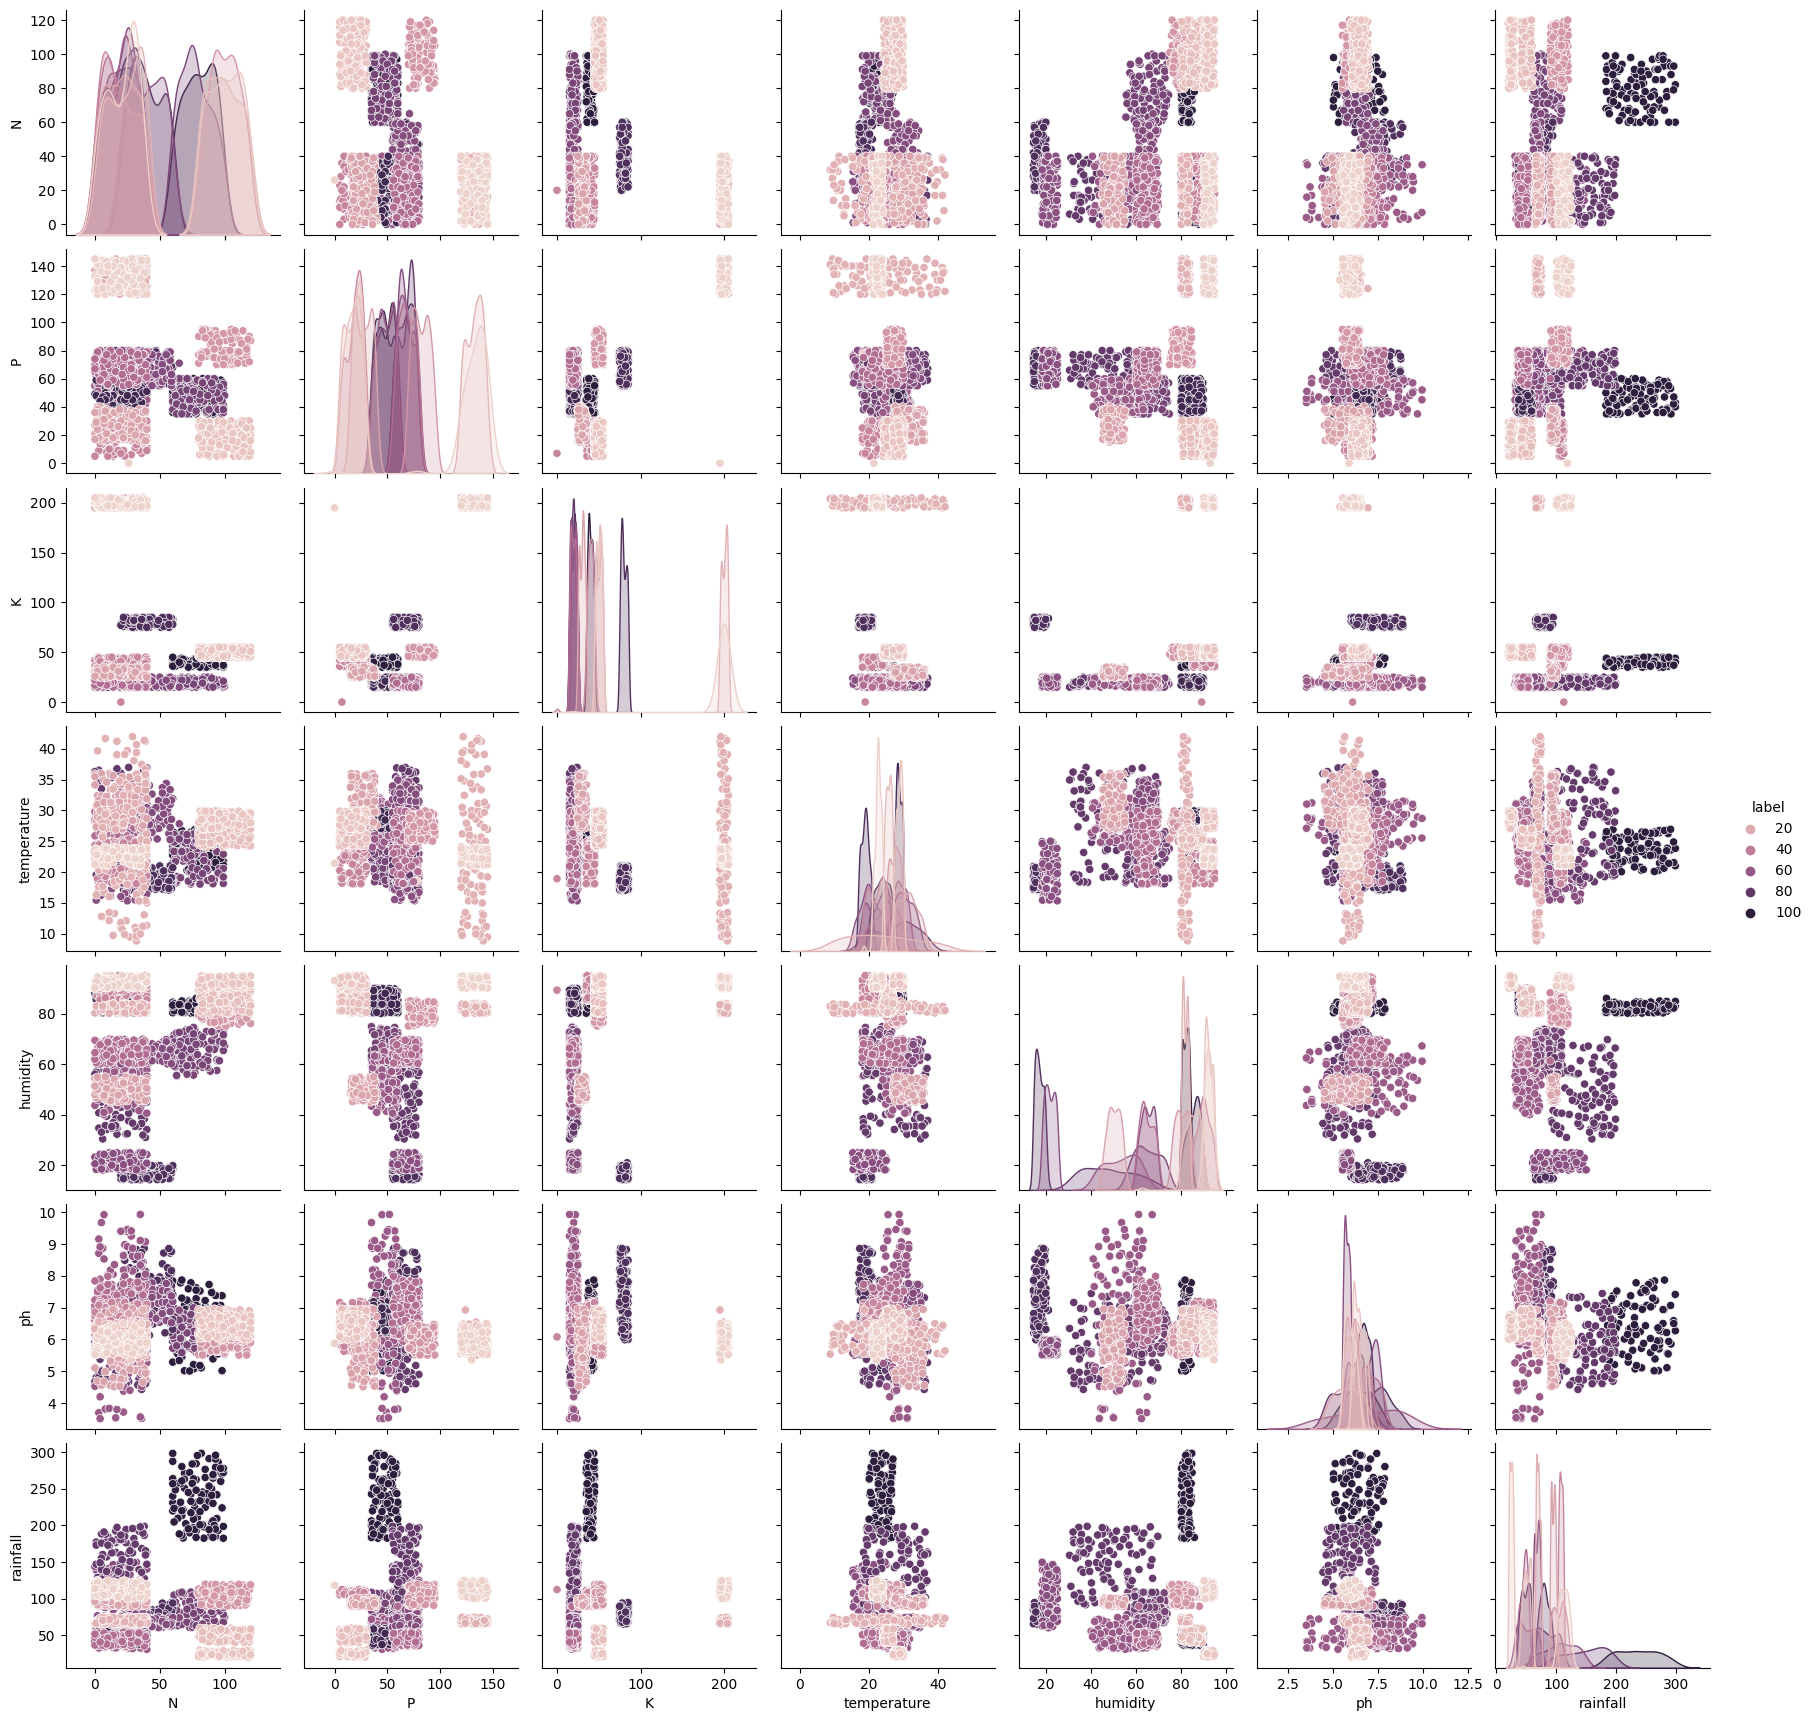

In [54]:
sns.pairplot(df,hue = 'label')

### Using Label Encoder function on column Water Usage

In [55]:
label_encoder = LabelEncoder()

In [56]:
df['Water Usage'] = label_encoder.fit_transform(df['Water Usage'])

In [57]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,Water Usage
0,90,42.0,43.0,20.879744,82.002744,6.502985,203.983200,100.0,2
1,85,58.0,41.0,22.000940,80.319644,7.038096,226.655537,100.0,2
2,60,55.0,44.0,23.004459,82.320763,7.840207,263.964248,100.0,0
3,74,35.0,40.0,26.491096,80.158363,6.980401,242.864034,100.0,2
4,78,42.0,42.0,20.130175,81.604873,7.628473,262.717340,100.0,0


### Splitting the dataframe into training and testing data

In [155]:
# Applying get dummies function on categorical column
x = df.drop('label',axis = 1)
y = df['label']

In [156]:
x_train , x_test , y_train , y_test = train_test_split(x,y, test_size = 0.30 , random_state = 10)

In [157]:
print("Dimension of x_train :",x_train.shape)
print("Dimension of x_test :",x_test.shape)
print("Dimension of y_train :",y_train.shape)
print("Dimension of y_test :",y_test.shape)

Dimension of x_train : (1120, 8)
Dimension of x_test : (480, 8)
Dimension of y_train : (1120,)
Dimension of y_test : (480,)


## Machine Learning Algorithms

### 1. Support Vector Machine

In [158]:
svm = SVC(kernel='linear')
svm.fit(x_train,y_train)

SVC(kernel='linear')

In [159]:
predict_svm = svm.predict(x_test)

In [160]:
predict_svm

array([  3.,  17.,  58.,  11.,  79.,  23.,  28.,  65.,  65.,   8.,  48.,
         8.,  72.,  11.,  72.,   8.,   3.,  11.,  65.,  92.,   3.,   3.,
         3., 100.,  86.,  17.,  58.,  72.,  86., 100.,  67.,  65.,  48.,
         8.,  36.,   3.,  79.,  86.,   3.,  48.,  28.,   3.,  23.,  65.,
        72.,  28.,  58.,  79.,  23., 100.,  65.,   8.,  36.,  28., 100.,
        23., 100.,  92.,   8.,  28.,   8.,  58.,   3.,  72.,  17.,  86.,
         8.,  58.,  11.,  79.,  36.,  48.,  72.,  23.,   3.,  11., 100.,
        65.,   3.,  36.,  23.,  72.,   8.,  92.,  65.,  48.,  58.,  86.,
       100.,  23.,  58.,   8.,   8.,  28.,   8.,   8.,  67.,  17.,  92.,
        28.,   8.,  86.,  65.,  11.,   8.,  67., 100.,  23.,  11.,  48.,
        36.,  28.,  65., 100.,  86.,  11.,  11.,  17.,  28.,  86.,   3.,
        79.,  11.,  92.,   8.,  67., 100.,  11.,  67.,  72.,  58.,  67.,
        48.,  79.,  65.,   8.,  92.,  79.,  92.,  79.,  36.,   3.,   8.,
         3., 100.,  86.,  48.,  92.,  92.,  67.,  1

In [161]:
print(confusion_matrix(y_test,predict_svm))

[[38  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 39  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 38  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 30  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 27  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 31  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 33  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 27  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 30  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 28  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 29  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 26  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 27  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 24  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 29]]


In [162]:
print(y_test)

1518     3.0
1246    17.0
544     58.0
1343    11.0
428     79.0
        ... 
174     72.0
387     65.0
1561     3.0
846     48.0
1568     3.0
Name: label, Length: 480, dtype: float64


In [186]:
y_pred = svm.predict(x_test)
print(accuracy_score(y_test,predict_svm))

0.9958333333333333


### 2.Random Forest Algorithm


In [171]:
rfc = RandomForestClassifier(n_estimators = 4,criterion = "entropy")

In [172]:
rfc.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy', n_estimators=4)

In [177]:
predict_rfc = rfc.predict(x_test)

In [178]:
predict_rfc

array([  3.,  17.,  58.,  11.,  79.,  23.,  28.,  65.,  65.,   8.,  48.,
         8.,  72.,  11.,  72.,   8.,   3.,  11.,  65.,  92.,   3.,   3.,
         3., 100.,  86.,  17.,  58.,  72.,  86., 100.,  67.,  65.,  48.,
         8.,  36.,   3.,  79.,  86.,   3.,  48.,  28.,   3.,  23.,  65.,
        72.,  28.,  58.,  79.,  23., 100.,  65.,   8.,  36.,  28., 100.,
        23., 100.,  92.,   8.,  28.,   8.,  58.,   3.,  72.,  17.,  86.,
         8.,  48.,  11.,  79.,  36.,  48.,  72.,  23.,   3.,  11., 100.,
        65.,   3.,  36.,  23.,  72.,   8.,  92.,  65.,  48.,  58.,  86.,
       100.,  23.,  58.,   8.,   8.,  28.,   8.,   8.,  67.,  17.,  92.,
        28.,   8.,  86.,  65.,  11.,   8.,  67., 100.,  23.,  11.,  48.,
        36.,  28.,  65., 100.,  86.,  11.,  11.,   3.,  28.,  86.,   3.,
        79.,  11.,  92.,   8.,  67., 100.,  11.,  67.,  72.,  58.,  67.,
        48.,  79.,  65.,   8.,  92.,  79.,  92.,  79.,  36.,   3.,   8.,
         3., 100.,  86.,  48.,  92.,  92.,  67.,  1

In [185]:
print(accuracy_score(y_test,predict_rfc))

0.9916666666666667


In [181]:
print(confusion_matrix(y_test,predict_rfc))

[[39  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 39  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 38  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 30  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 27  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 31  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 32  2  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 27  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 30  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  1  0 27  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 29  0  0  0  0]
 [ 0  0  0  0  1  0  0  0  0  0  0  0 25  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 27  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 24  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 29]]


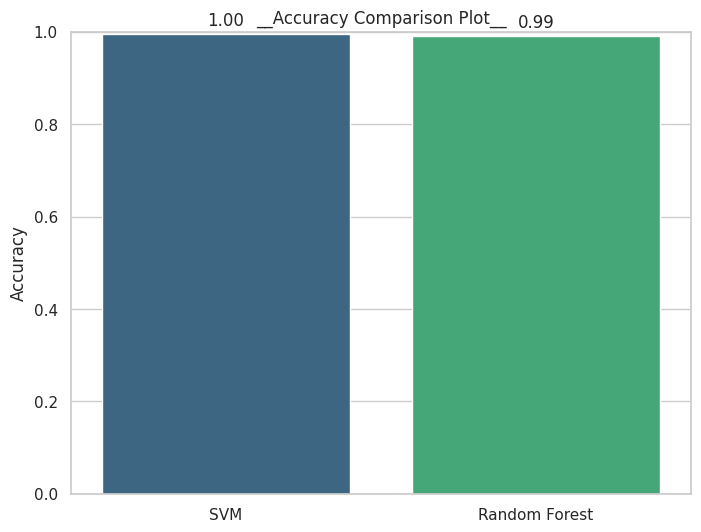

In [191]:

svm_accuracy = accuracy_score(y_test,y_pred)
rf_accuracy = accuracy_score(y_test,predict_rfc)

labels = ['SVM', 'Random Forest']
accuracies = [svm_accuracy, rf_accuracy]

sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))
plot = sns.barplot(x=labels, y=accuracies, palette="viridis")
plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.01, f'{value:.2f}', ha='center', va='bottom')

plt.title('__Accuracy Comparison Plot__')
plt.ylabel('Accuracy')
plt.show()

In [164]:
prediction = svm.predict((np.array([[98,24,53,34,76,14,252,0]])))
print("Your Agaricus bisporus Yeild is : ",prediction," %")

Your Agaricus bisporus Yeild is :  [100.]  %


In [165]:
prediction = svm.predict((np.array([[66,54,21,25,28,10,201,0]])))
print("Your Agaricus bisporus Yeild is : ",prediction," %")

Your Agaricus bisporus Yeild is :  [79.]  %
